# 2D Speckle Generation & Analysis

**Scott Prahl**

Adapted from the SimSpeckle Matlab script package described in Donald D. Duncan, Sean J. Kirkpatrick, "Algorithms for simulation of speckle (laser and otherwise)," Proc. SPIE 6855, Complex Dynamics and Fluctuations in Biomedical Photonics V, 685505 (6 February 2008); <https://doi.org/10.1117/12.760518>

The notebook is organized as

1. **apertures**, which set the size and shape of the speckle,
2. **fully developed speckle**, polarized through unpolarized,
3. **partially developed speckle**, from a rough surface that does not fully
   randomize the phase, and
4. **local contrast**, measured over a sliding window.

In [1]:
%config InlineBackend.figure_format = 'retina'

import sys
import imageio
import numpy as np
import matplotlib.pyplot as plt

if sys.platform == "emscripten":
    import piplite

    await piplite.install("pyspeckle")

import pyspeckle

# fix the seed so re-running this notebook reproduces the same figures
np.random.seed(0)

if sys.platform == "emscripten":
    repo = "images/"
else:
    repo = "https://github.com/scottprahl/pyspeckle/raw/main/docs/images/"

## Apertures set the speckle

Speckle is produced by illuminating an aperture with randomly phased light and
propagating to the far field.  The aperture is not an implementation detail:
its *size* fixes the speckle size, and its *shape* fixes the speckle shape.  A
wide aperture gives fine speckle, a narrow one gives coarse speckle, and an
elongated aperture gives speckle elongated the other way.

`pyspeckle` builds the aperture with a private helper, `_create_mask`.  It is
not exported, but it is worth looking at first because everything else follows
from it.

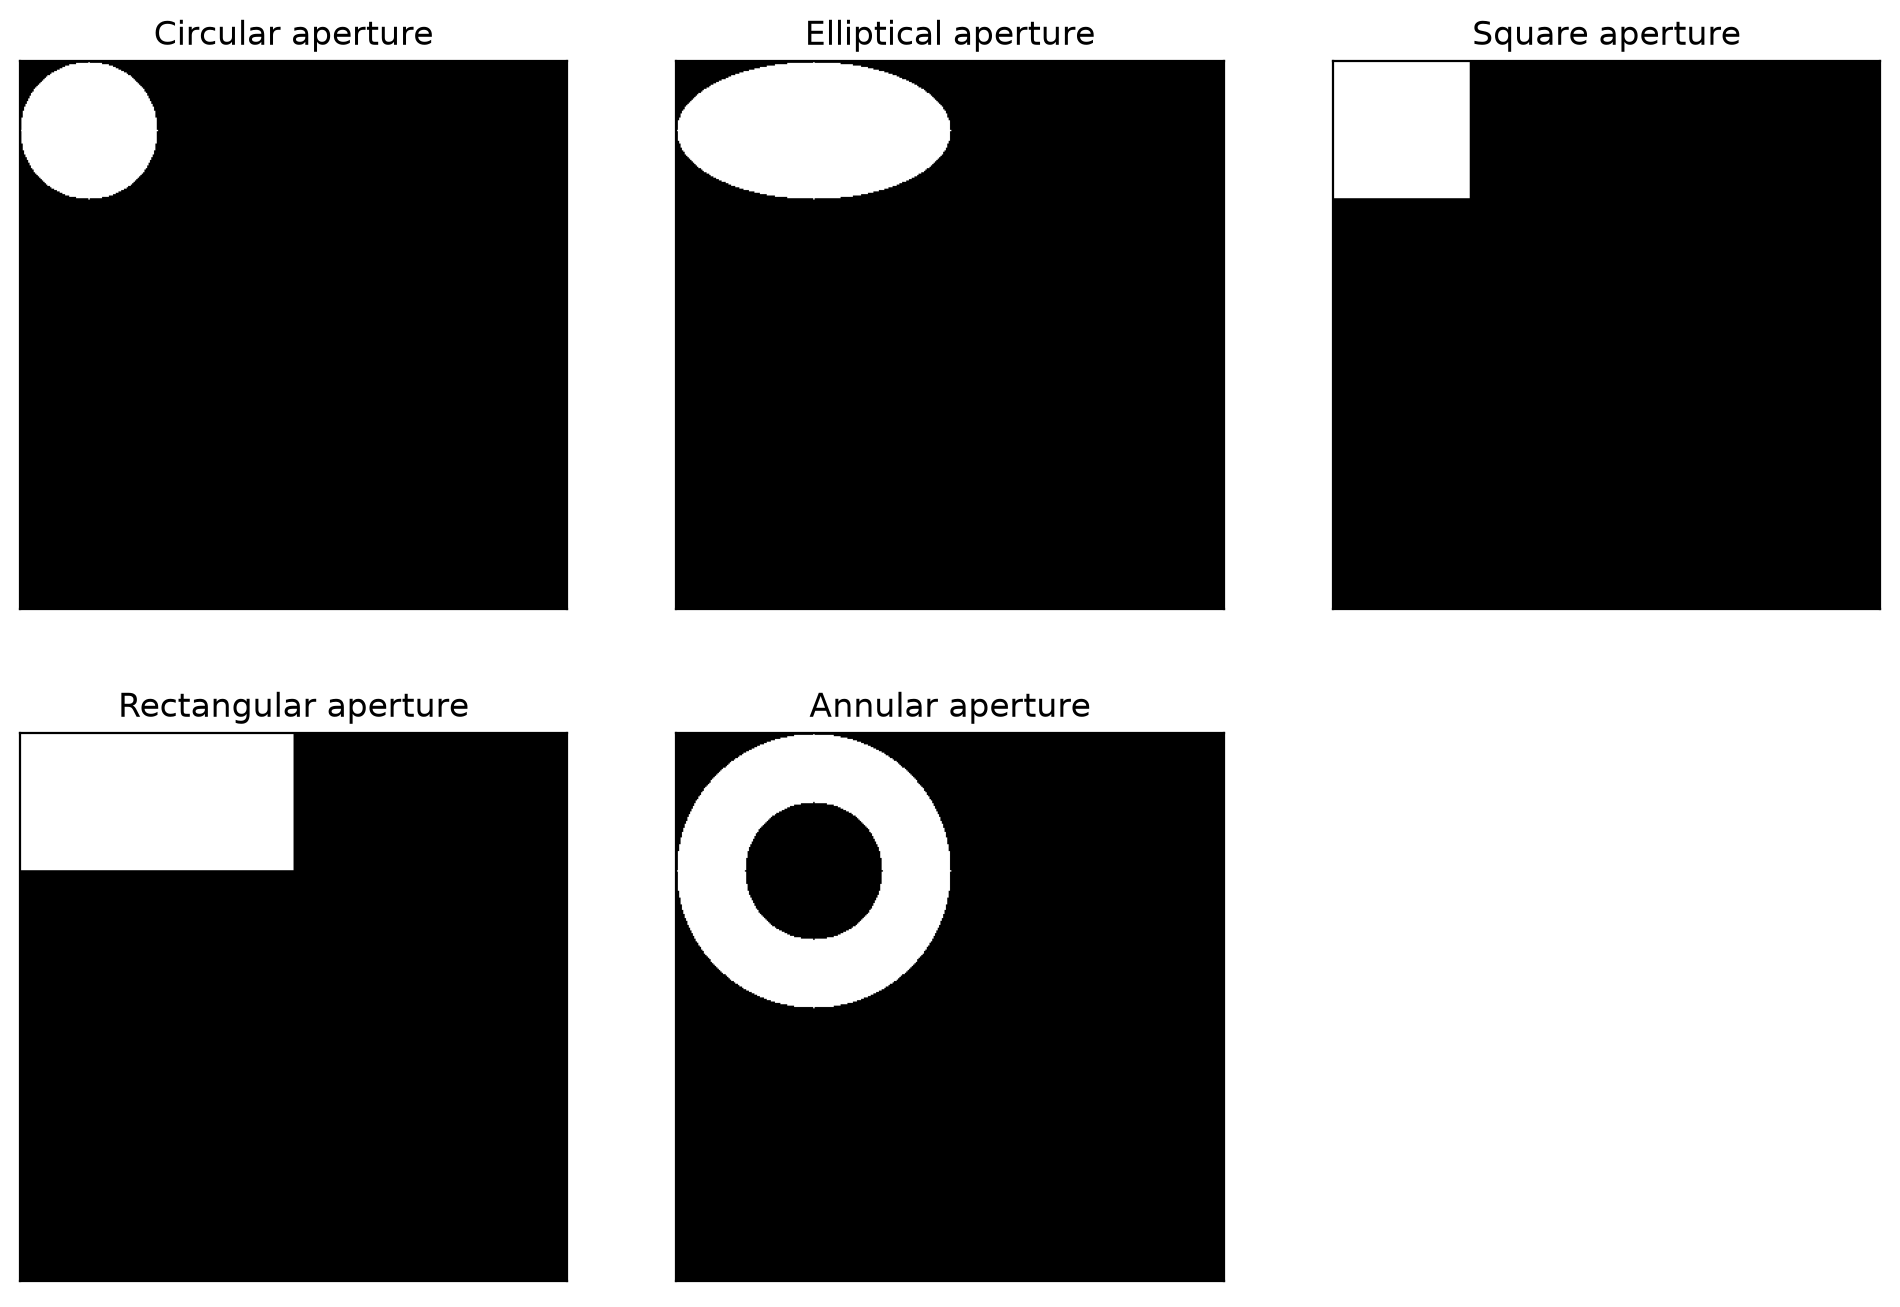

In [2]:
N, L, R = 400, 100, 50

plt.subplots(2, 3, figsize=(12, 8))
for i, (title, args, kwargs) in enumerate(
    [
        ("Circular", (N, R, R), {}),
        ("Elliptical", (N, L, R), {}),
        ("Square", (N, R, R), {"shape": "square"}),
        ("Rectangular", (N, L, R), {"shape": "square"}),
        ("Annular", (N, R, L), {"shape": "annulus"}),
    ]
):
    plt.subplot(2, 3, i + 1)
    plt.imshow(pyspeckle.core._create_mask(*args, **kwargs), cmap="gray")
    plt.title(title + " aperture")
    plt.xticks([])
    plt.yticks([])

plt.subplot(2, 3, 6)
plt.axis("off")
plt.show()

### From aperture to speckle

The recipe is short: fill the aperture with uniform random phase, Fourier
transform, and take the squared magnitude.  Doing it by hand shows how
directly the aperture controls the result.  A circular aperture gives round
speckle; an aperture stretched horizontally gives speckle stretched
vertically.

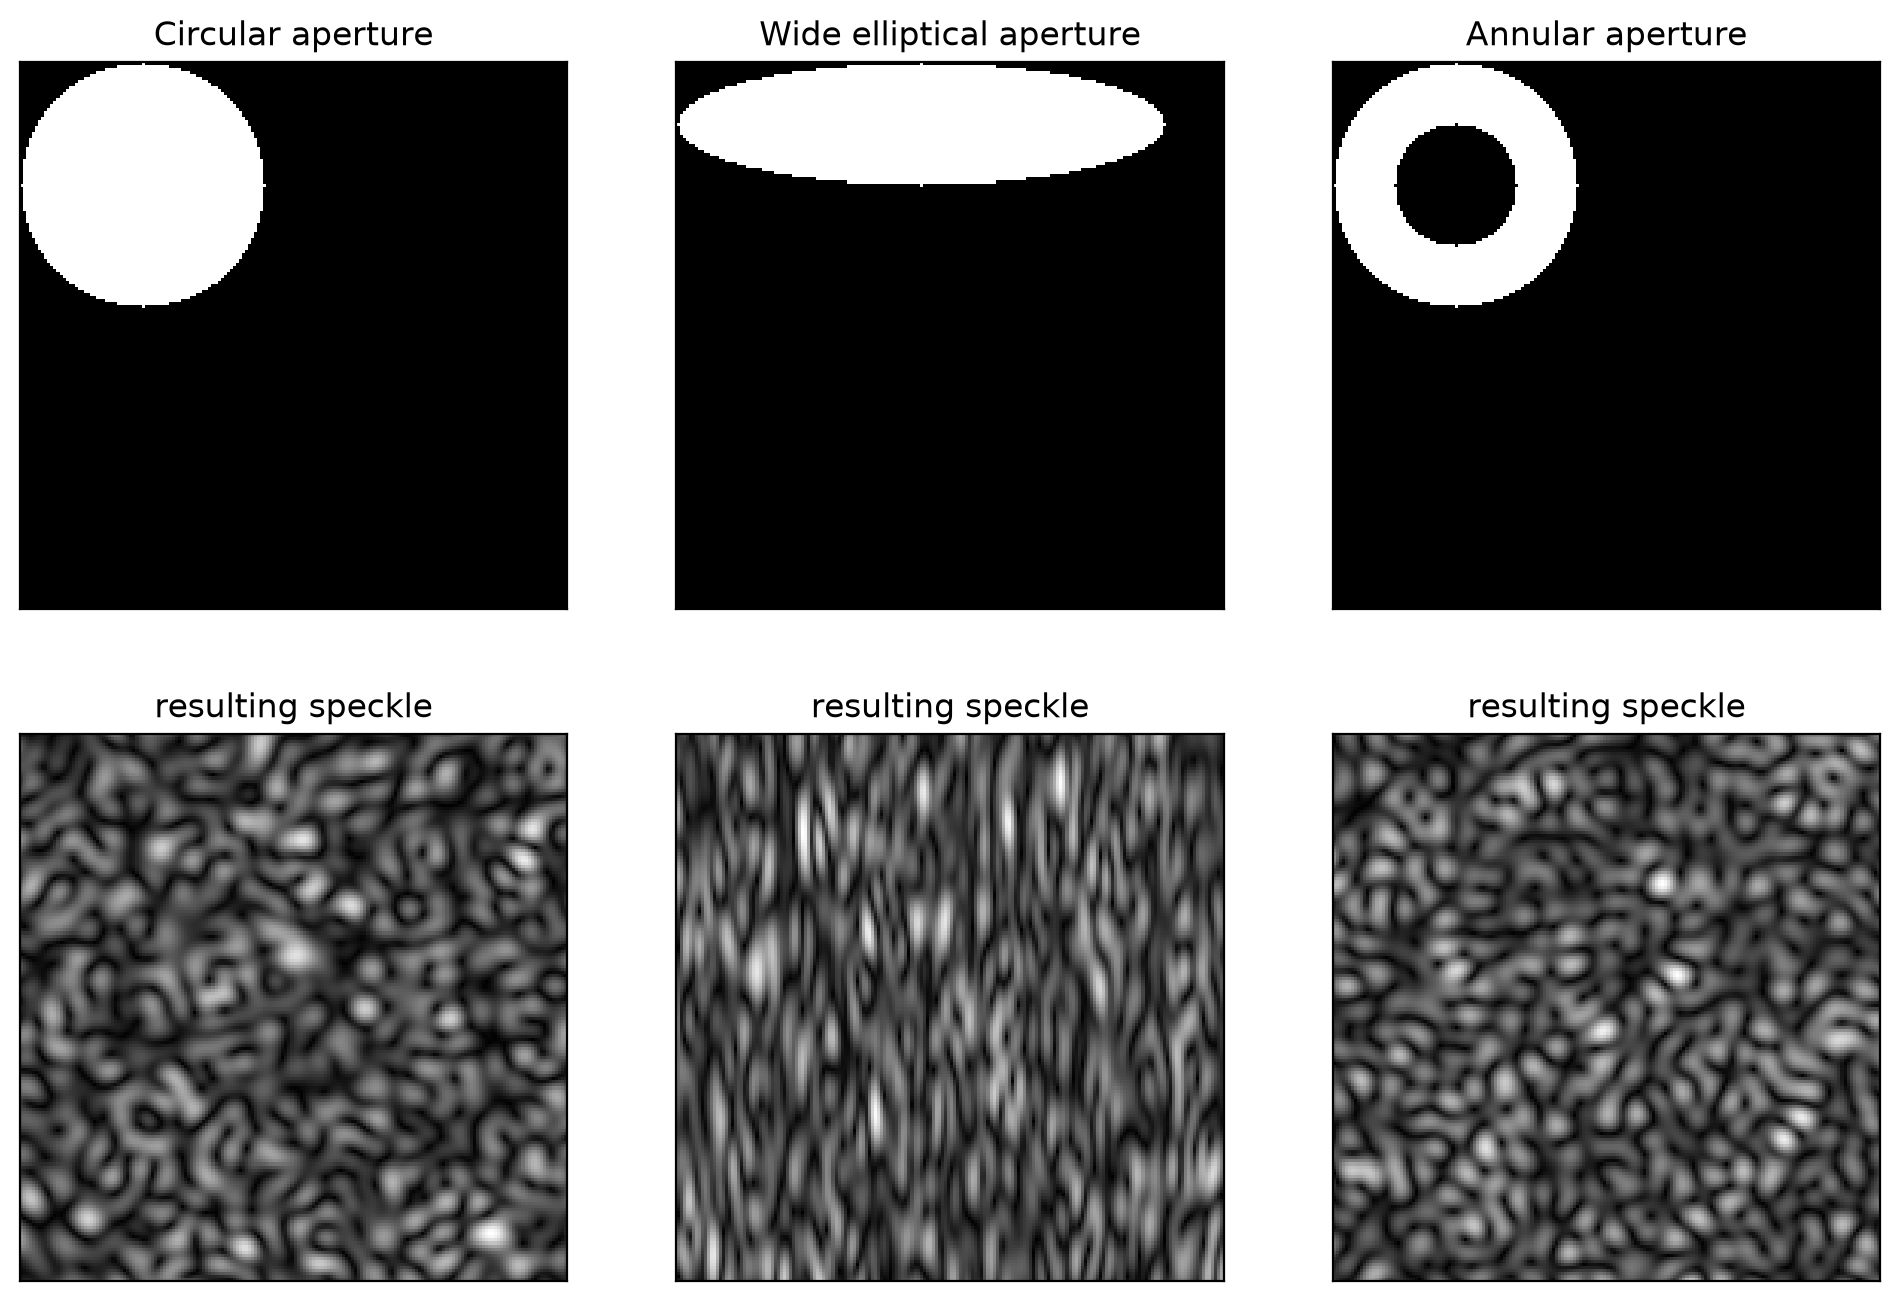

In [3]:
N = 512
apertures = [
    ("Circular", (N, 40, 40), {}),
    ("Wide elliptical", (N, 80, 20), {}),
    ("Annular", (N, 20, 40), {"shape": "annulus"}),
]

plt.subplots(2, 3, figsize=(12, 8))
for i, (title, args, kwargs) in enumerate(apertures):
    mask = pyspeckle.core._create_mask(*args, **kwargs)

    plt.subplot(2, 3, i + 1)
    plt.imshow(mask[:180, :180], cmap="gray")
    plt.title(title + " aperture")
    plt.xticks([])
    plt.yticks([])

    field = np.exp(1j * 2 * np.pi * np.random.rand(N, N)) * mask
    speckle = np.abs(np.fft.fftshift(np.fft.fft2(field))) ** 2

    plt.subplot(2, 3, i + 4)
    plt.imshow(np.sqrt(speckle[:180, :180]), cmap="gray")
    plt.title("resulting speckle")
    plt.xticks([])
    plt.yticks([])

plt.show()

## Fully developed speckle

When the surface is rough compared with the wavelength the scattered phase is
uniform over $2\pi$ and the speckle is fully developed.  The irradiance is
exponentially distributed and the speckle contrast, the standard deviation
divided by the mean, is one.

`statistics_plot` shows the pattern, its histogram, the power spectral
density, and the same histogram on a log scale.  The PSD reveals the sampling:
when it fills the frame the pattern is at the Nyquist limit of two pixels per
speckle.

### Two pixels per speckle, the Nyquist limit

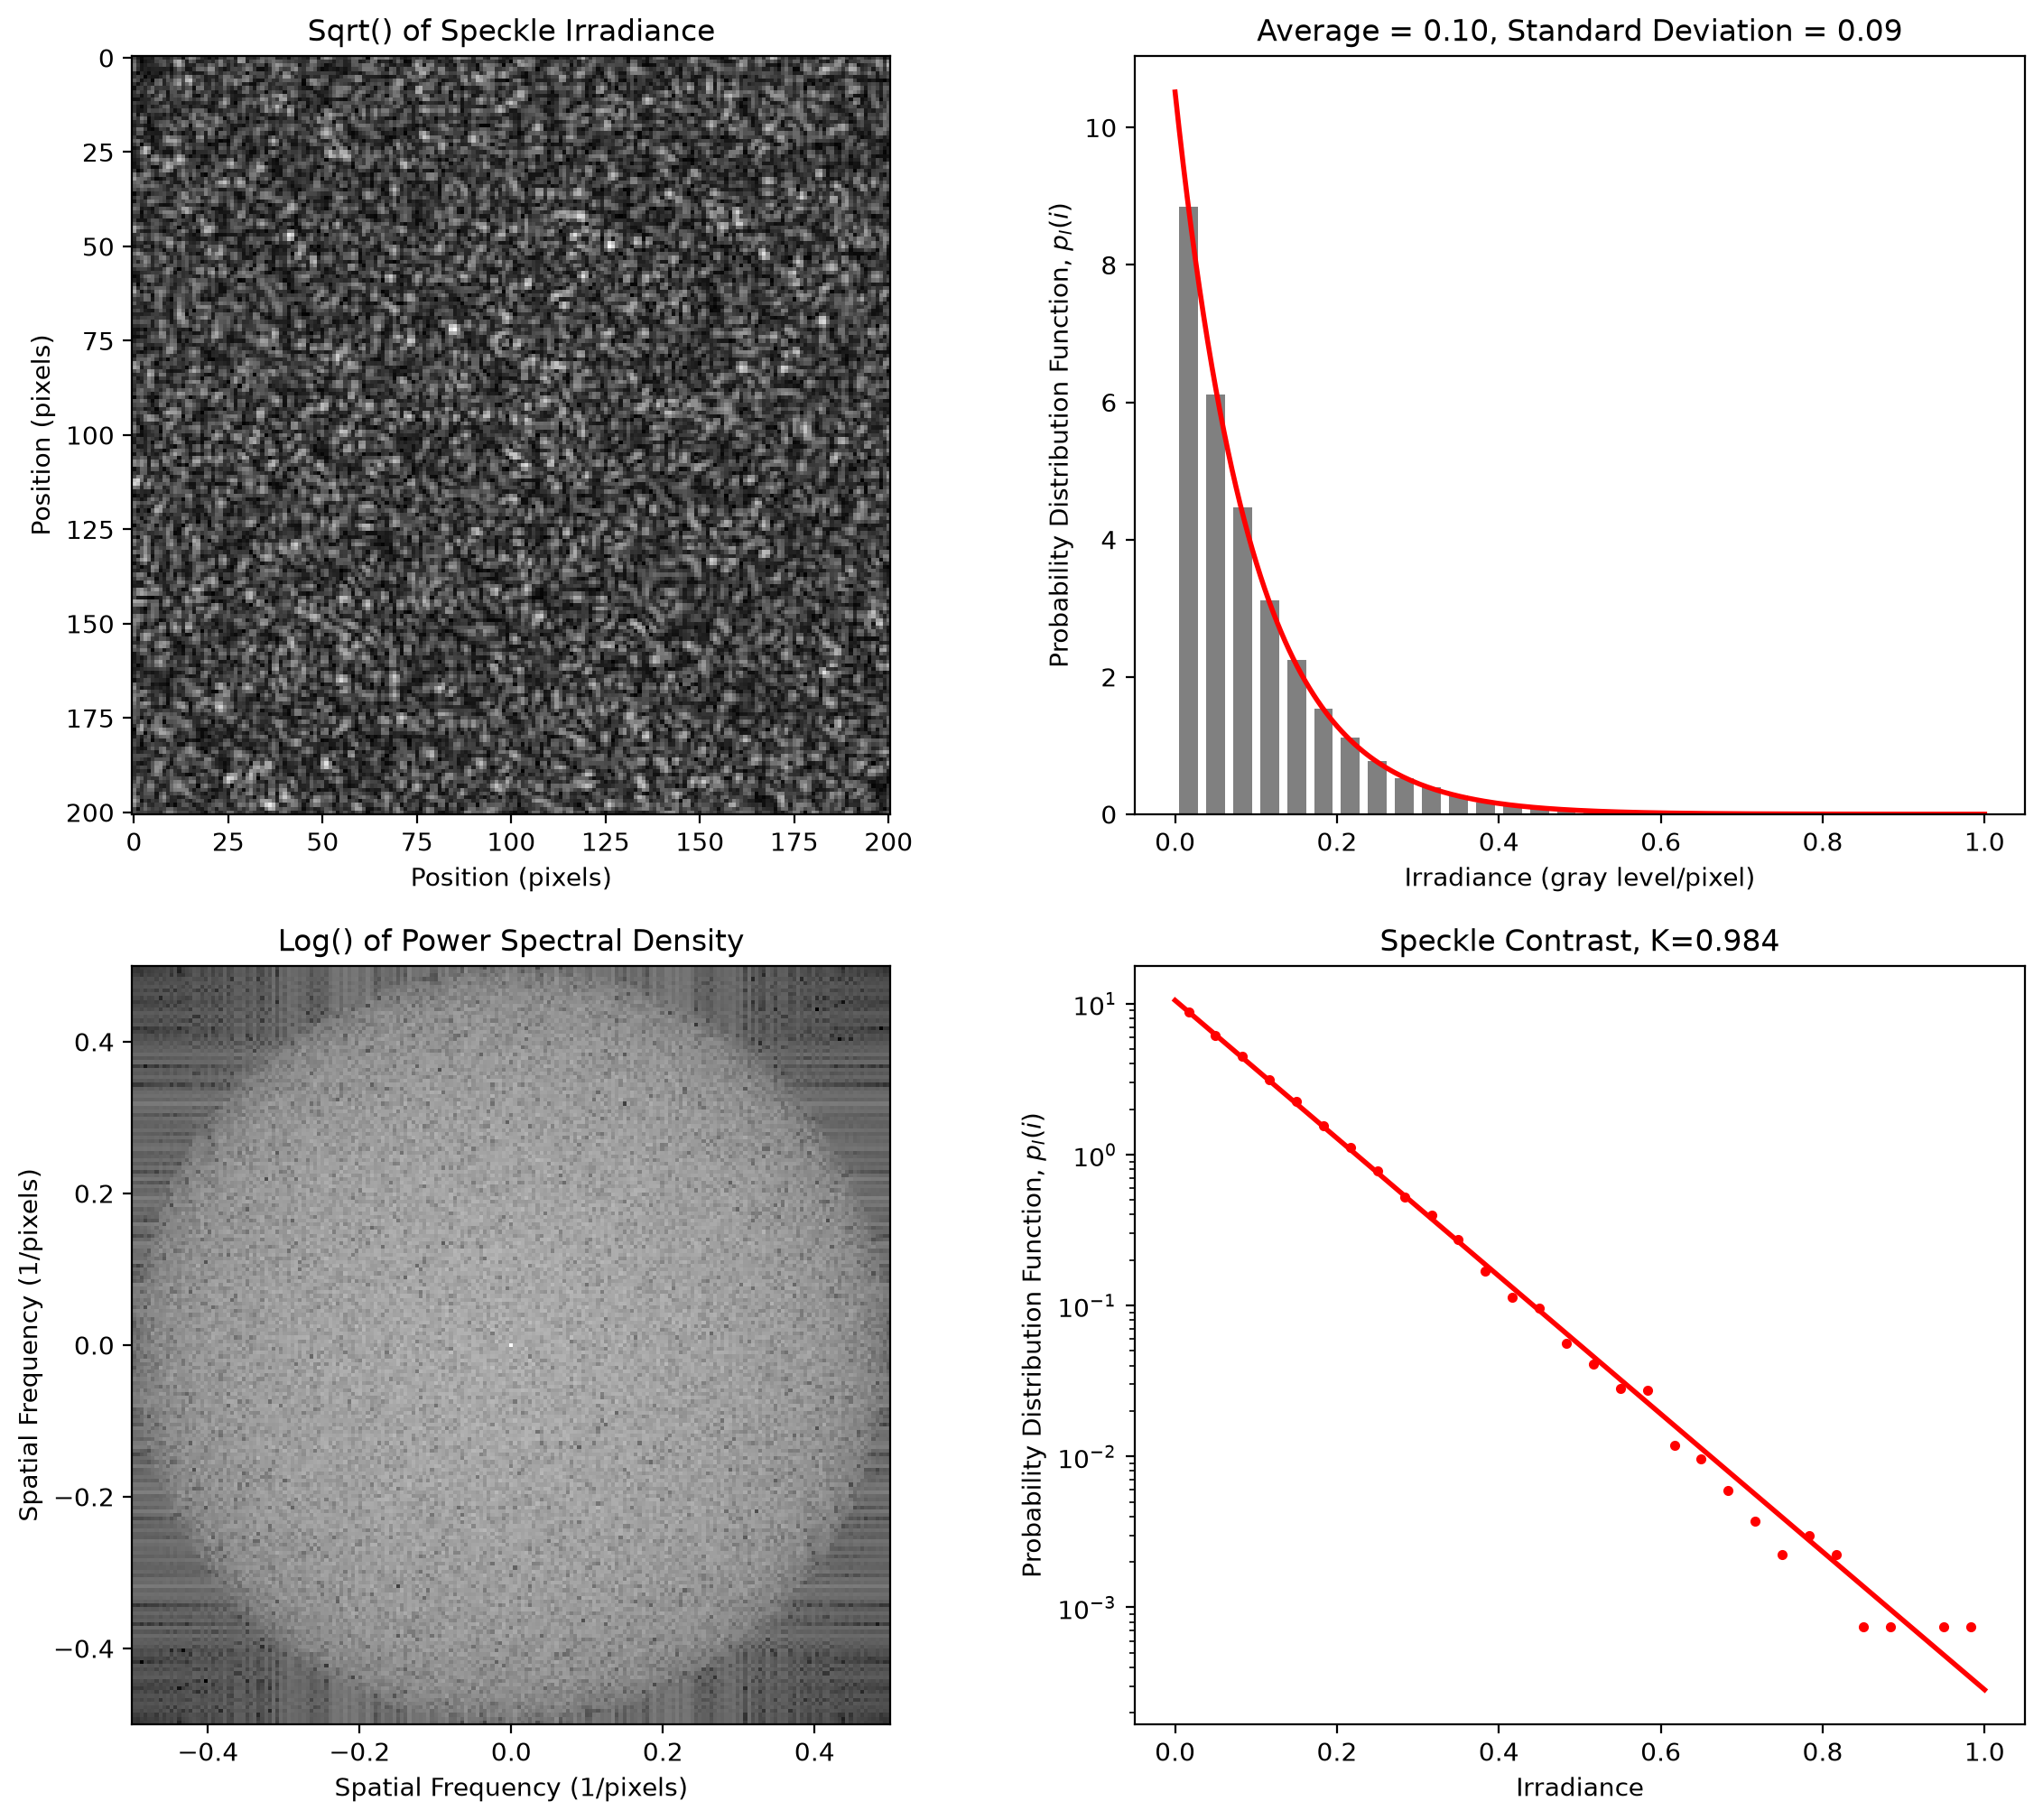

contrast K = 0.984 (theory 1)


In [4]:
y = pyspeckle.create_exponential((201, 201), 2)
pyspeckle.statistics_plot(y)
# theoretical exponential PDF over both histogram panels
g = np.linspace(0, y.max(), 200)
pdf = np.exp(-g / y.mean()) / y.mean()
plt.subplot(222)
plt.plot(g, pdf, "r", lw=2)
plt.subplot(224)
plt.semilogy(g, pdf, "r", lw=2)

plt.show()

print("contrast K = %.3f (theory 1)" % (np.std(y) / np.mean(y)))

### Ten pixels per speckle

Increasing `pix_per_speckle` oversamples the same statistics: the speckles get
visibly larger and the power spectral density shrinks to the middle of the
frame.  The contrast is unchanged, because contrast is a first-order statistic
and does not depend on how finely the pattern is sampled.

The image does have to hold enough speckles for the measurement to settle.
This one is about 20 speckles across, so roughly 400 in total, and the measured
contrast lands within a few percent of 1.  Coarser sampling would put fewer
speckles in the same frame and the estimate would scatter more from one
realization to the next.


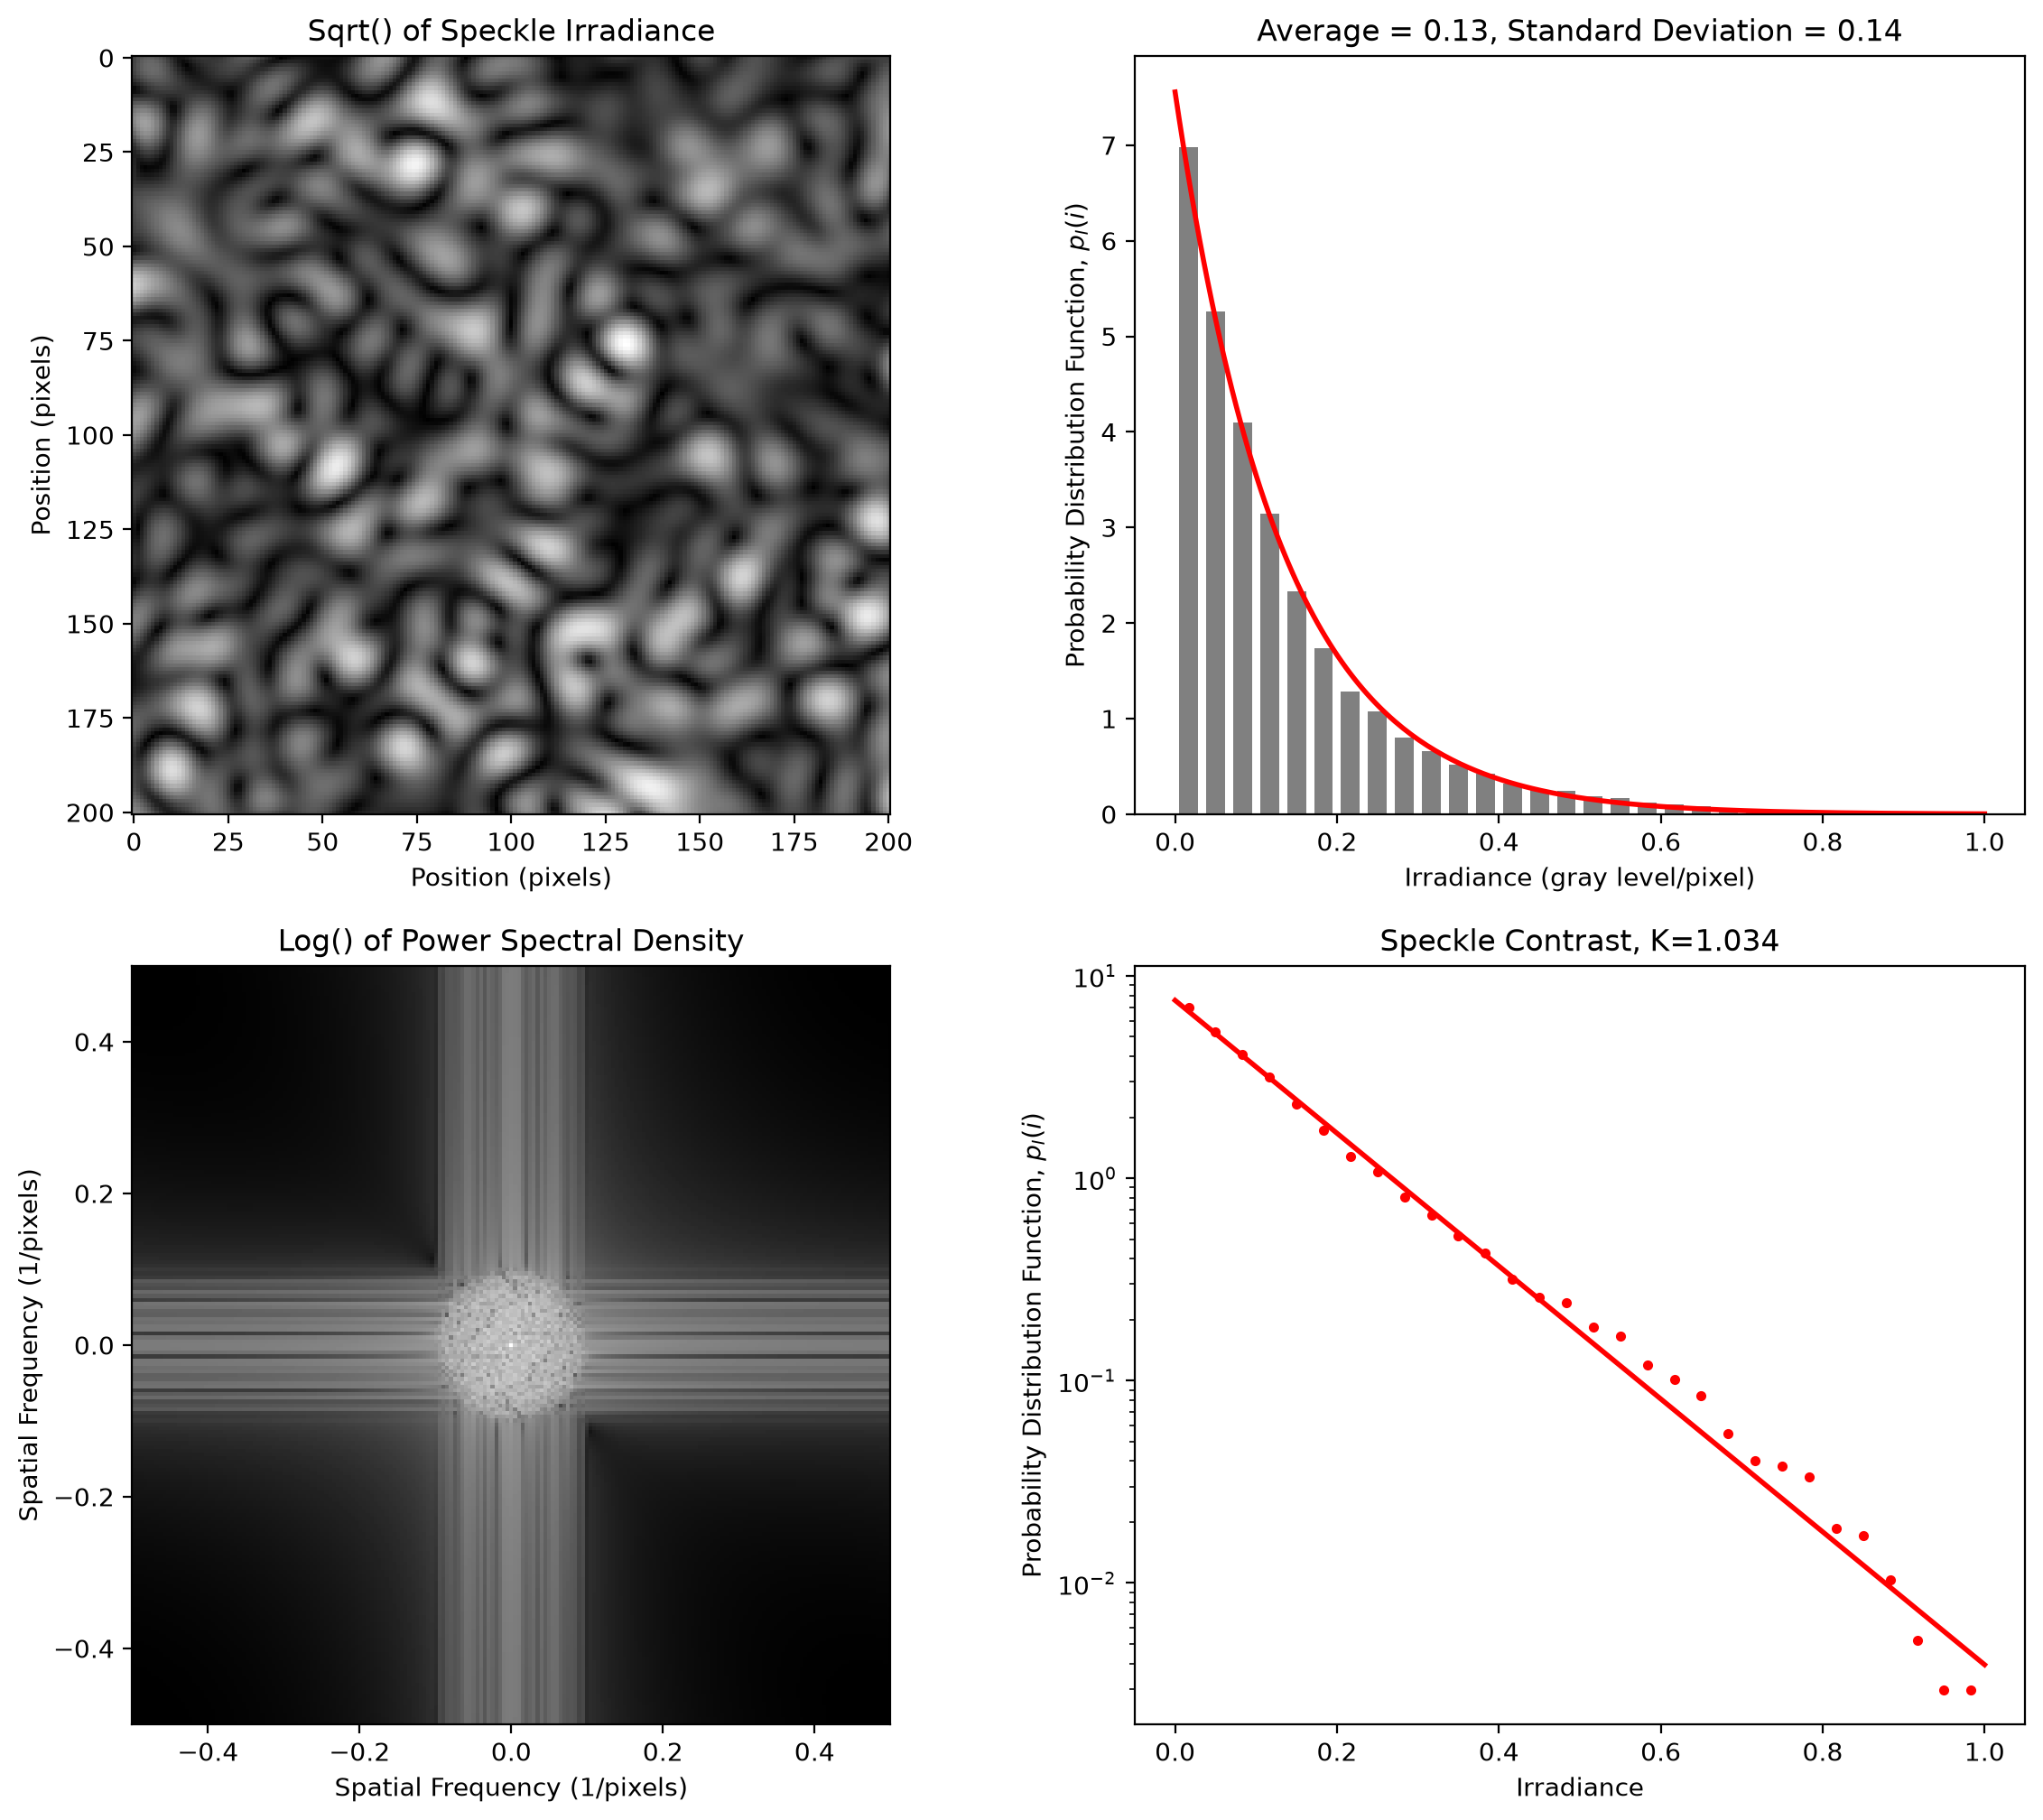

contrast K = 1.034 (unchanged by sampling)


In [5]:
y = pyspeckle.create_exponential((201, 201), 10)
pyspeckle.statistics_plot(y)
# theoretical exponential PDF over both histogram panels
g = np.linspace(0, y.max(), 200)
pdf = np.exp(-g / y.mean()) / y.mean()
plt.subplot(222)
plt.plot(g, pdf, "r", lw=2)
plt.subplot(224)
plt.semilogy(g, pdf, "r", lw=2)

plt.show()

print("contrast K = %.3f (unchanged by sampling)" % (np.std(y) / np.mean(y)))

### Anisotropic speckle

`alpha` is the ratio of horizontal to vertical speckle size.  `alpha=0.5`
gives speckle that is twice as tall as it is wide.

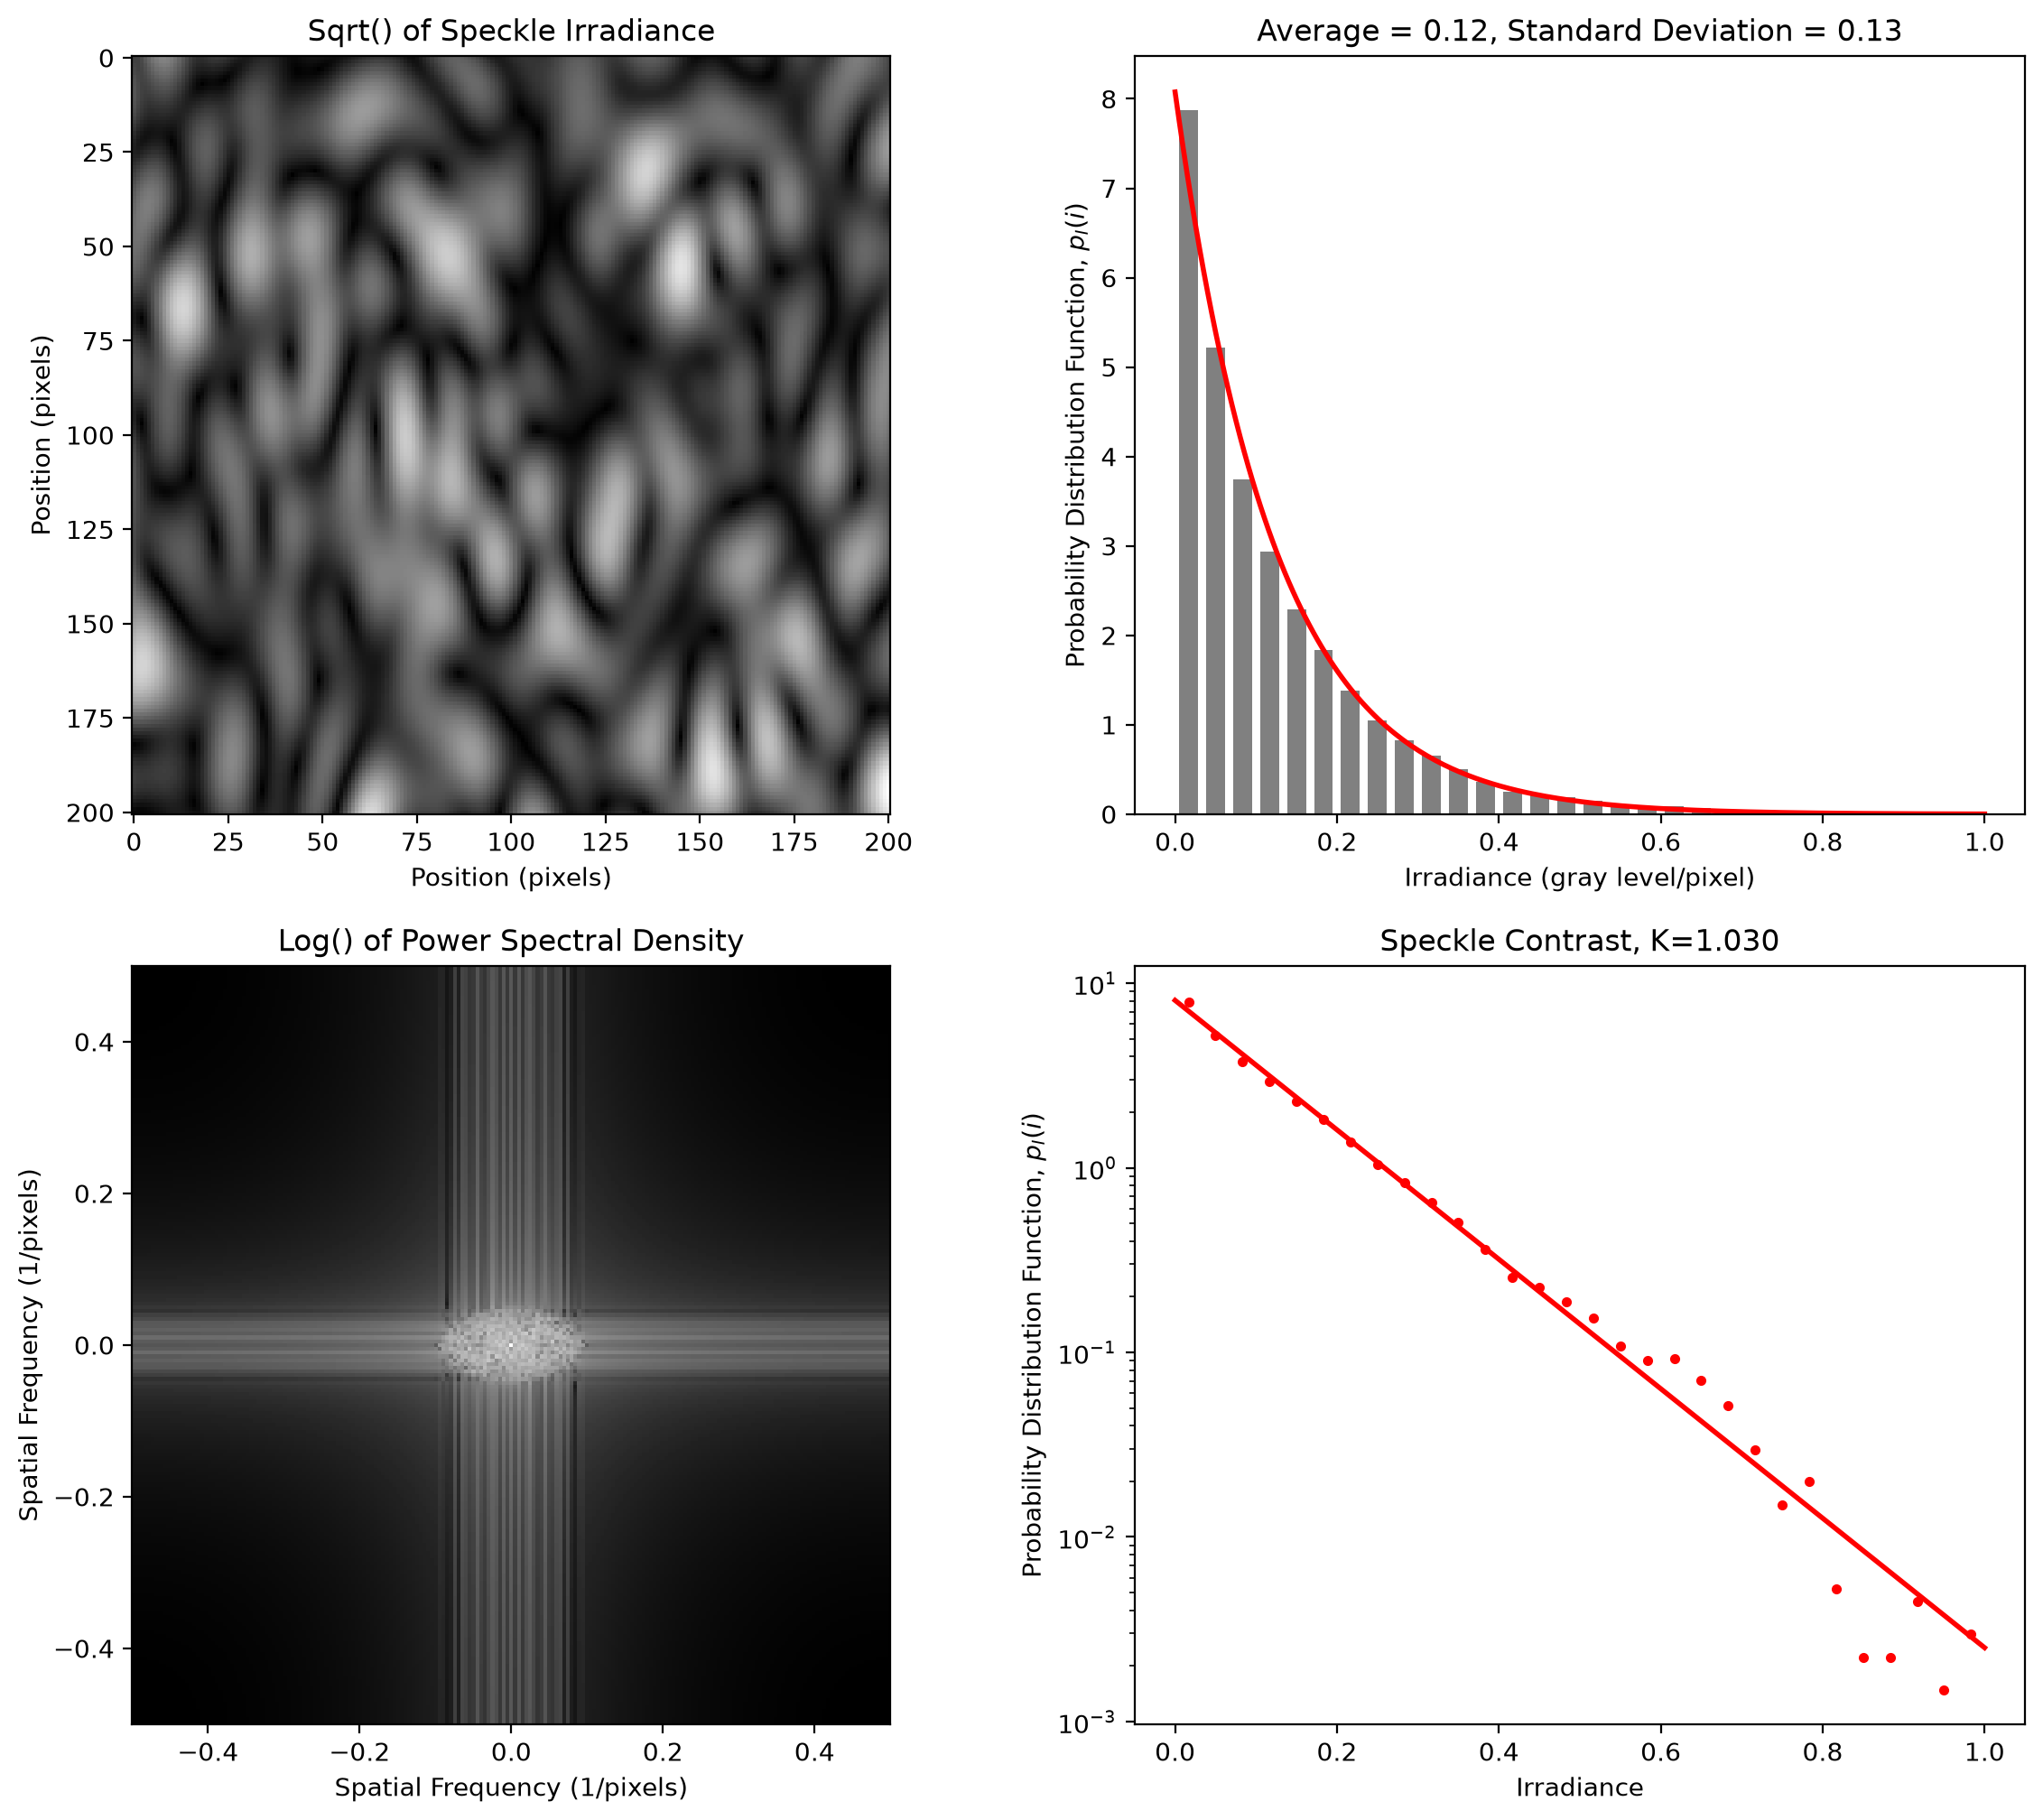

In [6]:
y = pyspeckle.create_exponential((201, 201), 10, alpha=0.5)
pyspeckle.statistics_plot(y)
# theoretical exponential PDF over both histogram panels
g = np.linspace(0, y.max(), 200)
pdf = np.exp(-g / y.mean()) / y.mean()
plt.subplot(222)
plt.plot(g, pdf, "r", lw=2)
plt.subplot(224)
plt.semilogy(g, pdf, "r", lw=2)

plt.show()

### Square and annular apertures

The aperture shape carries through to the speckle and to the power spectral
density, which takes the shape of the aperture.

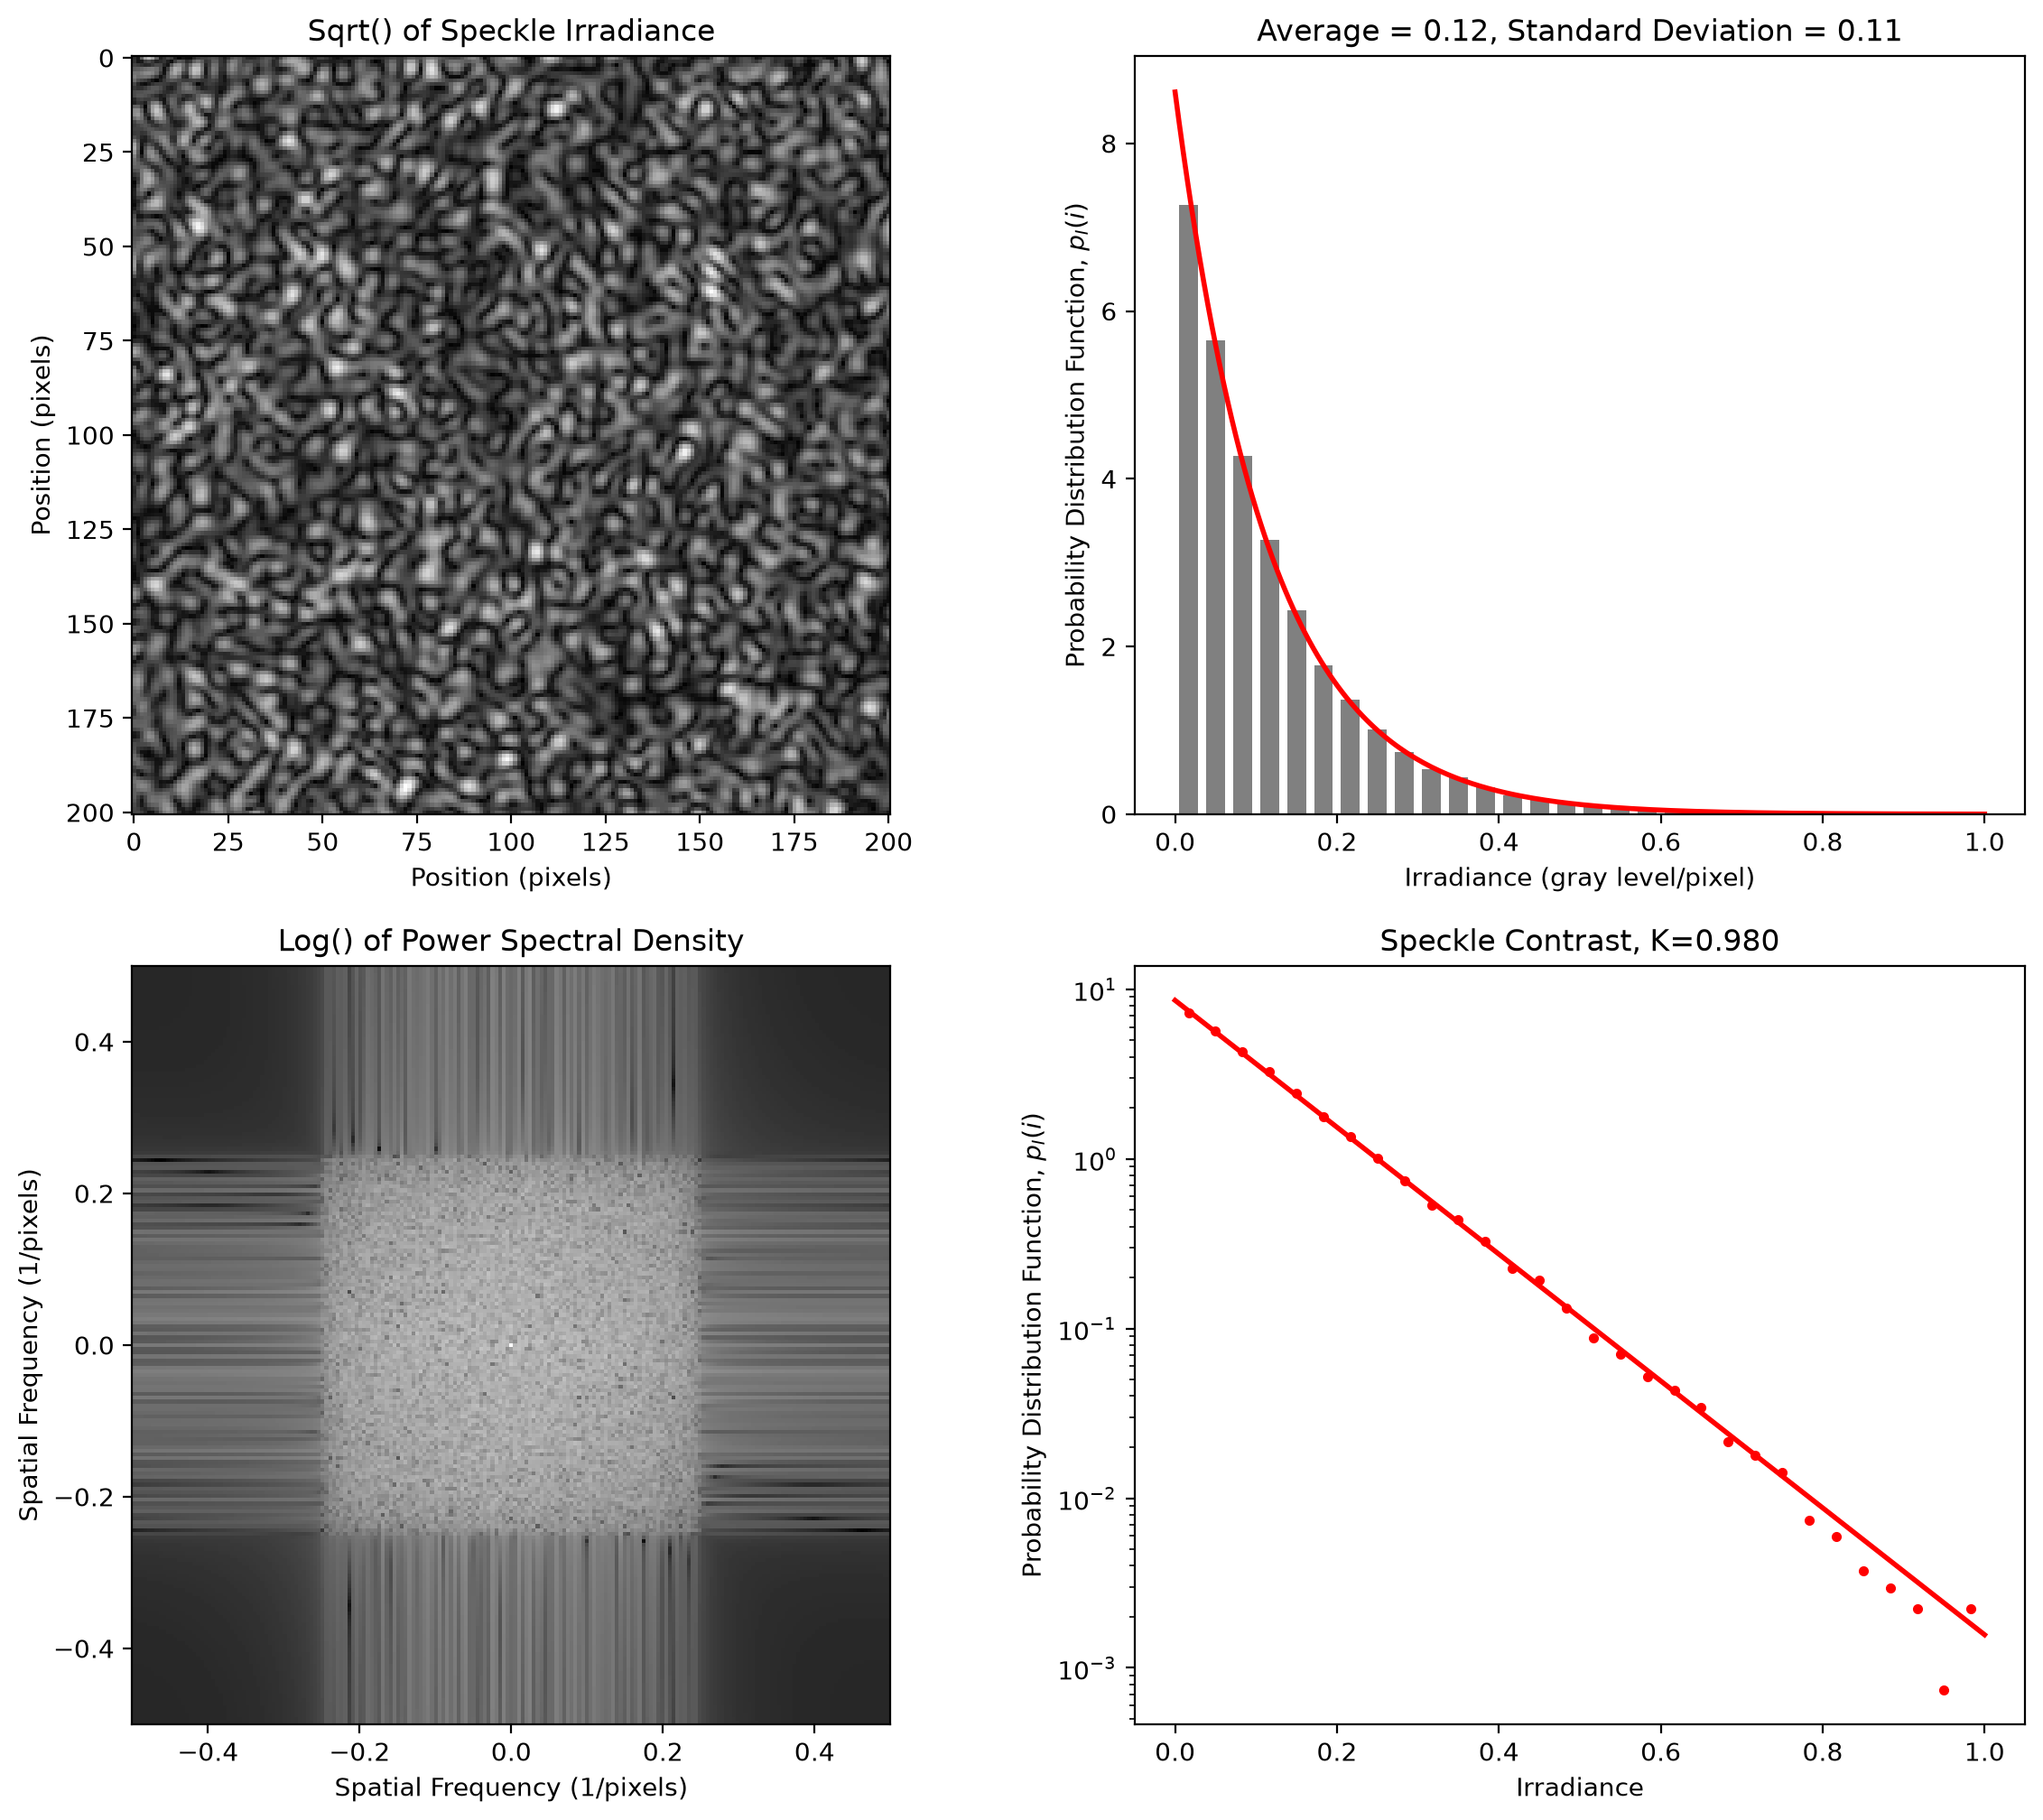

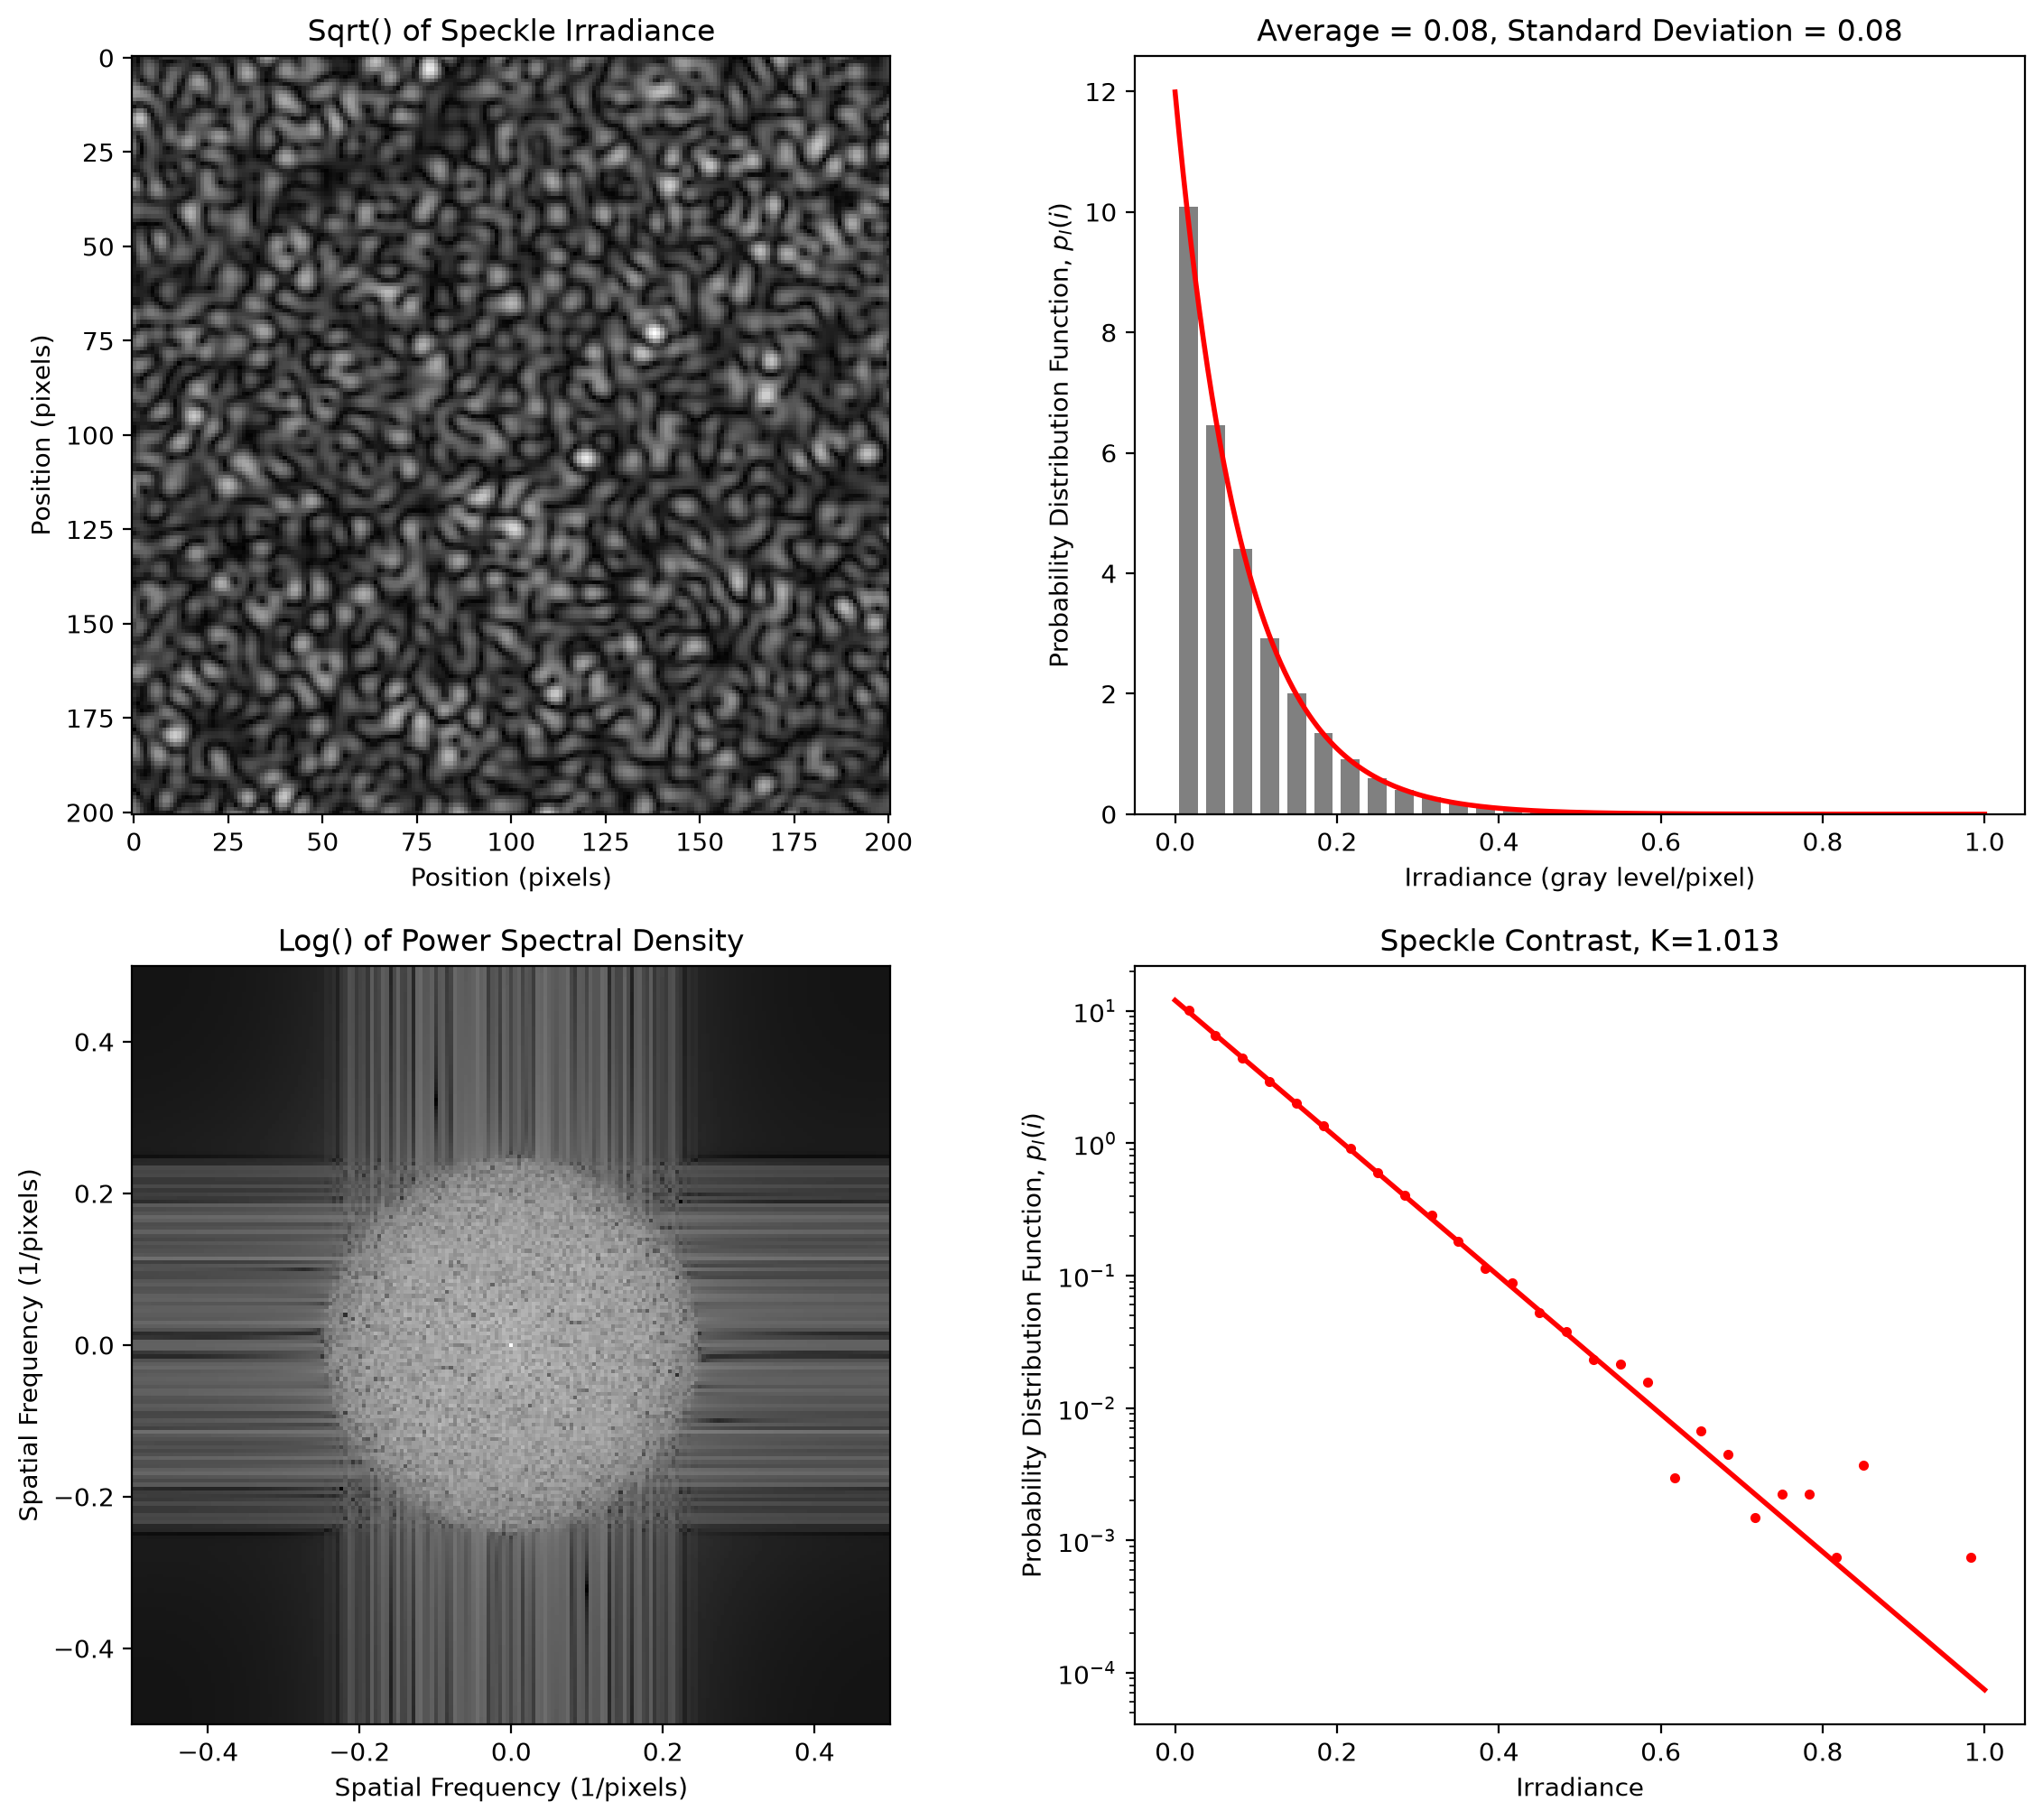

In [7]:
y = pyspeckle.create_exponential((201, 201), 4, aperture="square")
pyspeckle.statistics_plot(y)
# theoretical exponential PDF over both histogram panels
g = np.linspace(0, y.max(), 200)
pdf = np.exp(-g / y.mean()) / y.mean()
plt.subplot(222)
plt.plot(g, pdf, "r", lw=2)
plt.subplot(224)
plt.semilogy(g, pdf, "r", lw=2)

plt.show()

y = pyspeckle.create_exponential((201, 201), 4, aperture="annulus", alpha=3)
pyspeckle.statistics_plot(y)
# the aperture changes the speckle shape but not the irradiance distribution
g = np.linspace(0, y.max(), 200)
pdf = np.exp(-g / y.mean()) / y.mean()
plt.subplot(222)
plt.plot(g, pdf, "r", lw=2)
plt.subplot(224)
plt.semilogy(g, pdf, "r", lw=2)

plt.show()

### Degree of polarization

`polarization=1` is fully polarized light with unit contrast.  Lower values mix
in a second, independent speckle pattern, and the contrast falls smoothly to
$1/\sqrt{2}$ at `polarization=0`.

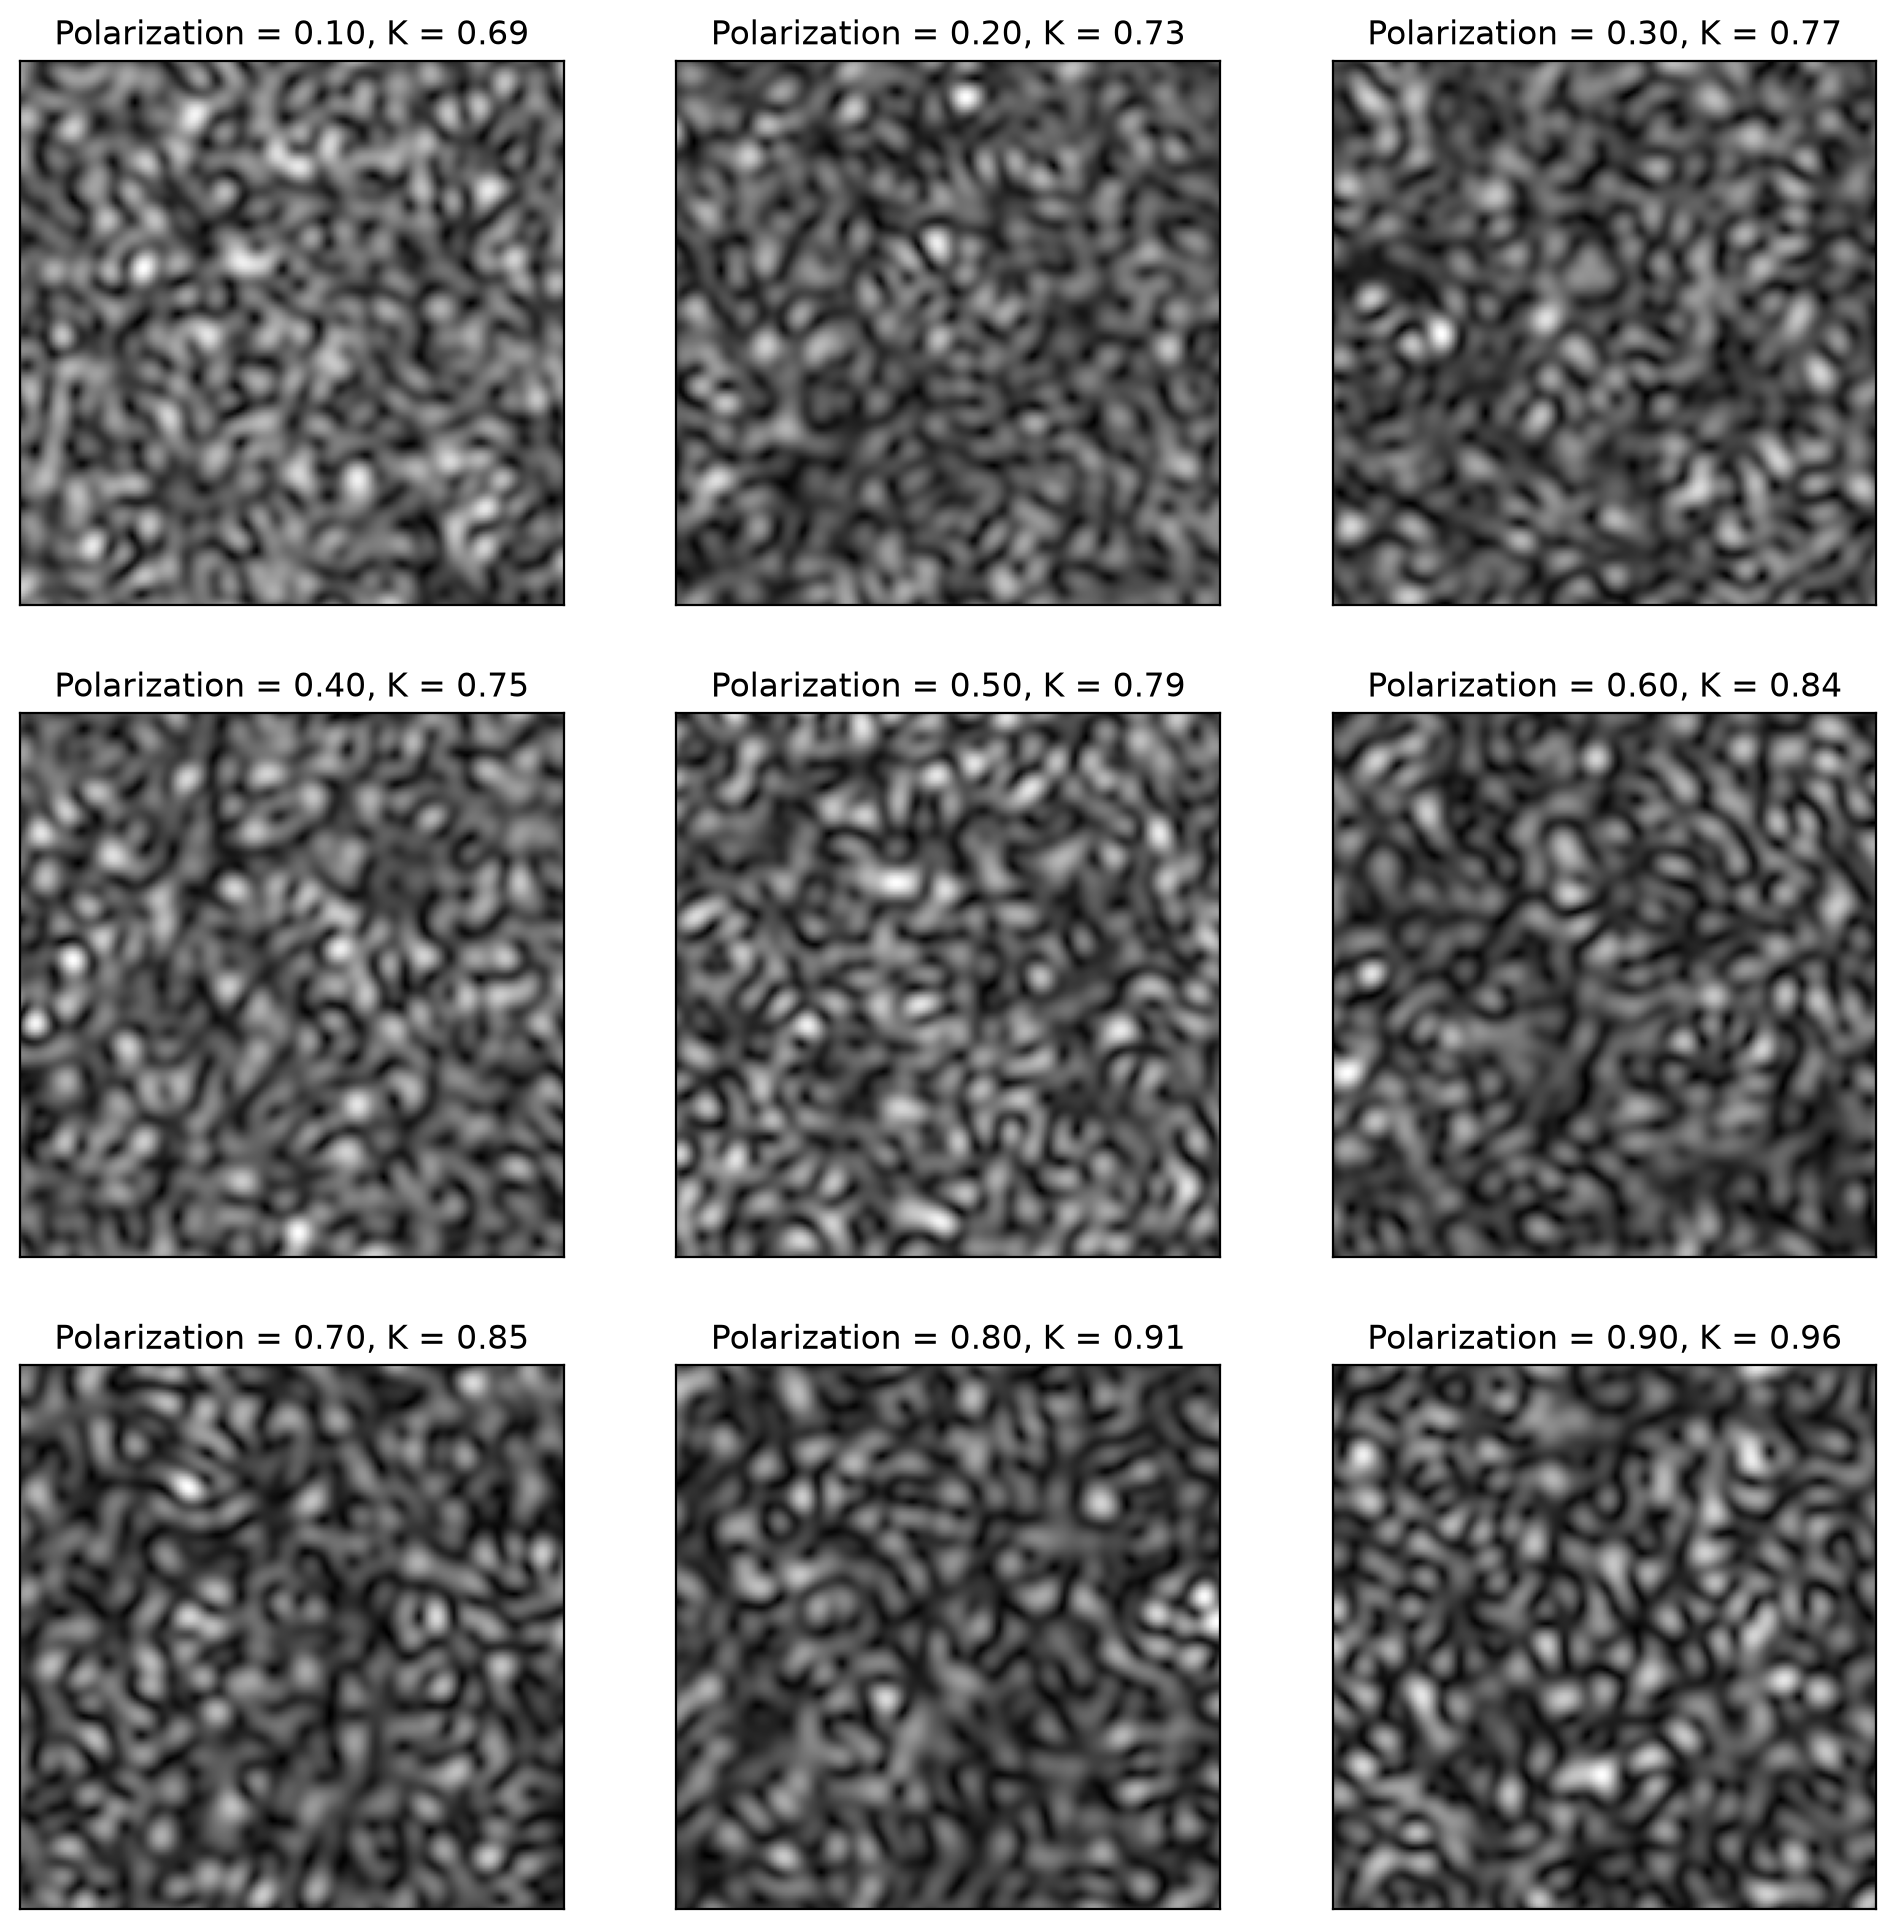

In [8]:
plt.subplots(3, 3, figsize=(12, 12))
for i, pol in enumerate([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]):
    plt.subplot(3, 3, i + 1)
    y = pyspeckle.create_exponential((201, 201), 8, polarization=pol)
    plt.imshow(np.sqrt(y), cmap="gray")
    plt.title("Polarization = %.2f, K = %.2f" % (pol, np.std(y) / np.mean(y)))
    plt.xticks([])
    plt.yticks([])

plt.show()

### Unpolarized speckle

Unpolarized light adds two independent speckle patterns, one per polarization
state.  The irradiance follows a gamma distribution with shape 2 and the
contrast is $1/\sqrt{2}\approx0.707$.  Duncan & Kirkpatrick call this the
Rayleigh limit of zero polarization.

`create_unpolarized` is exactly `create_exponential((..., ...), polarization=0)`.

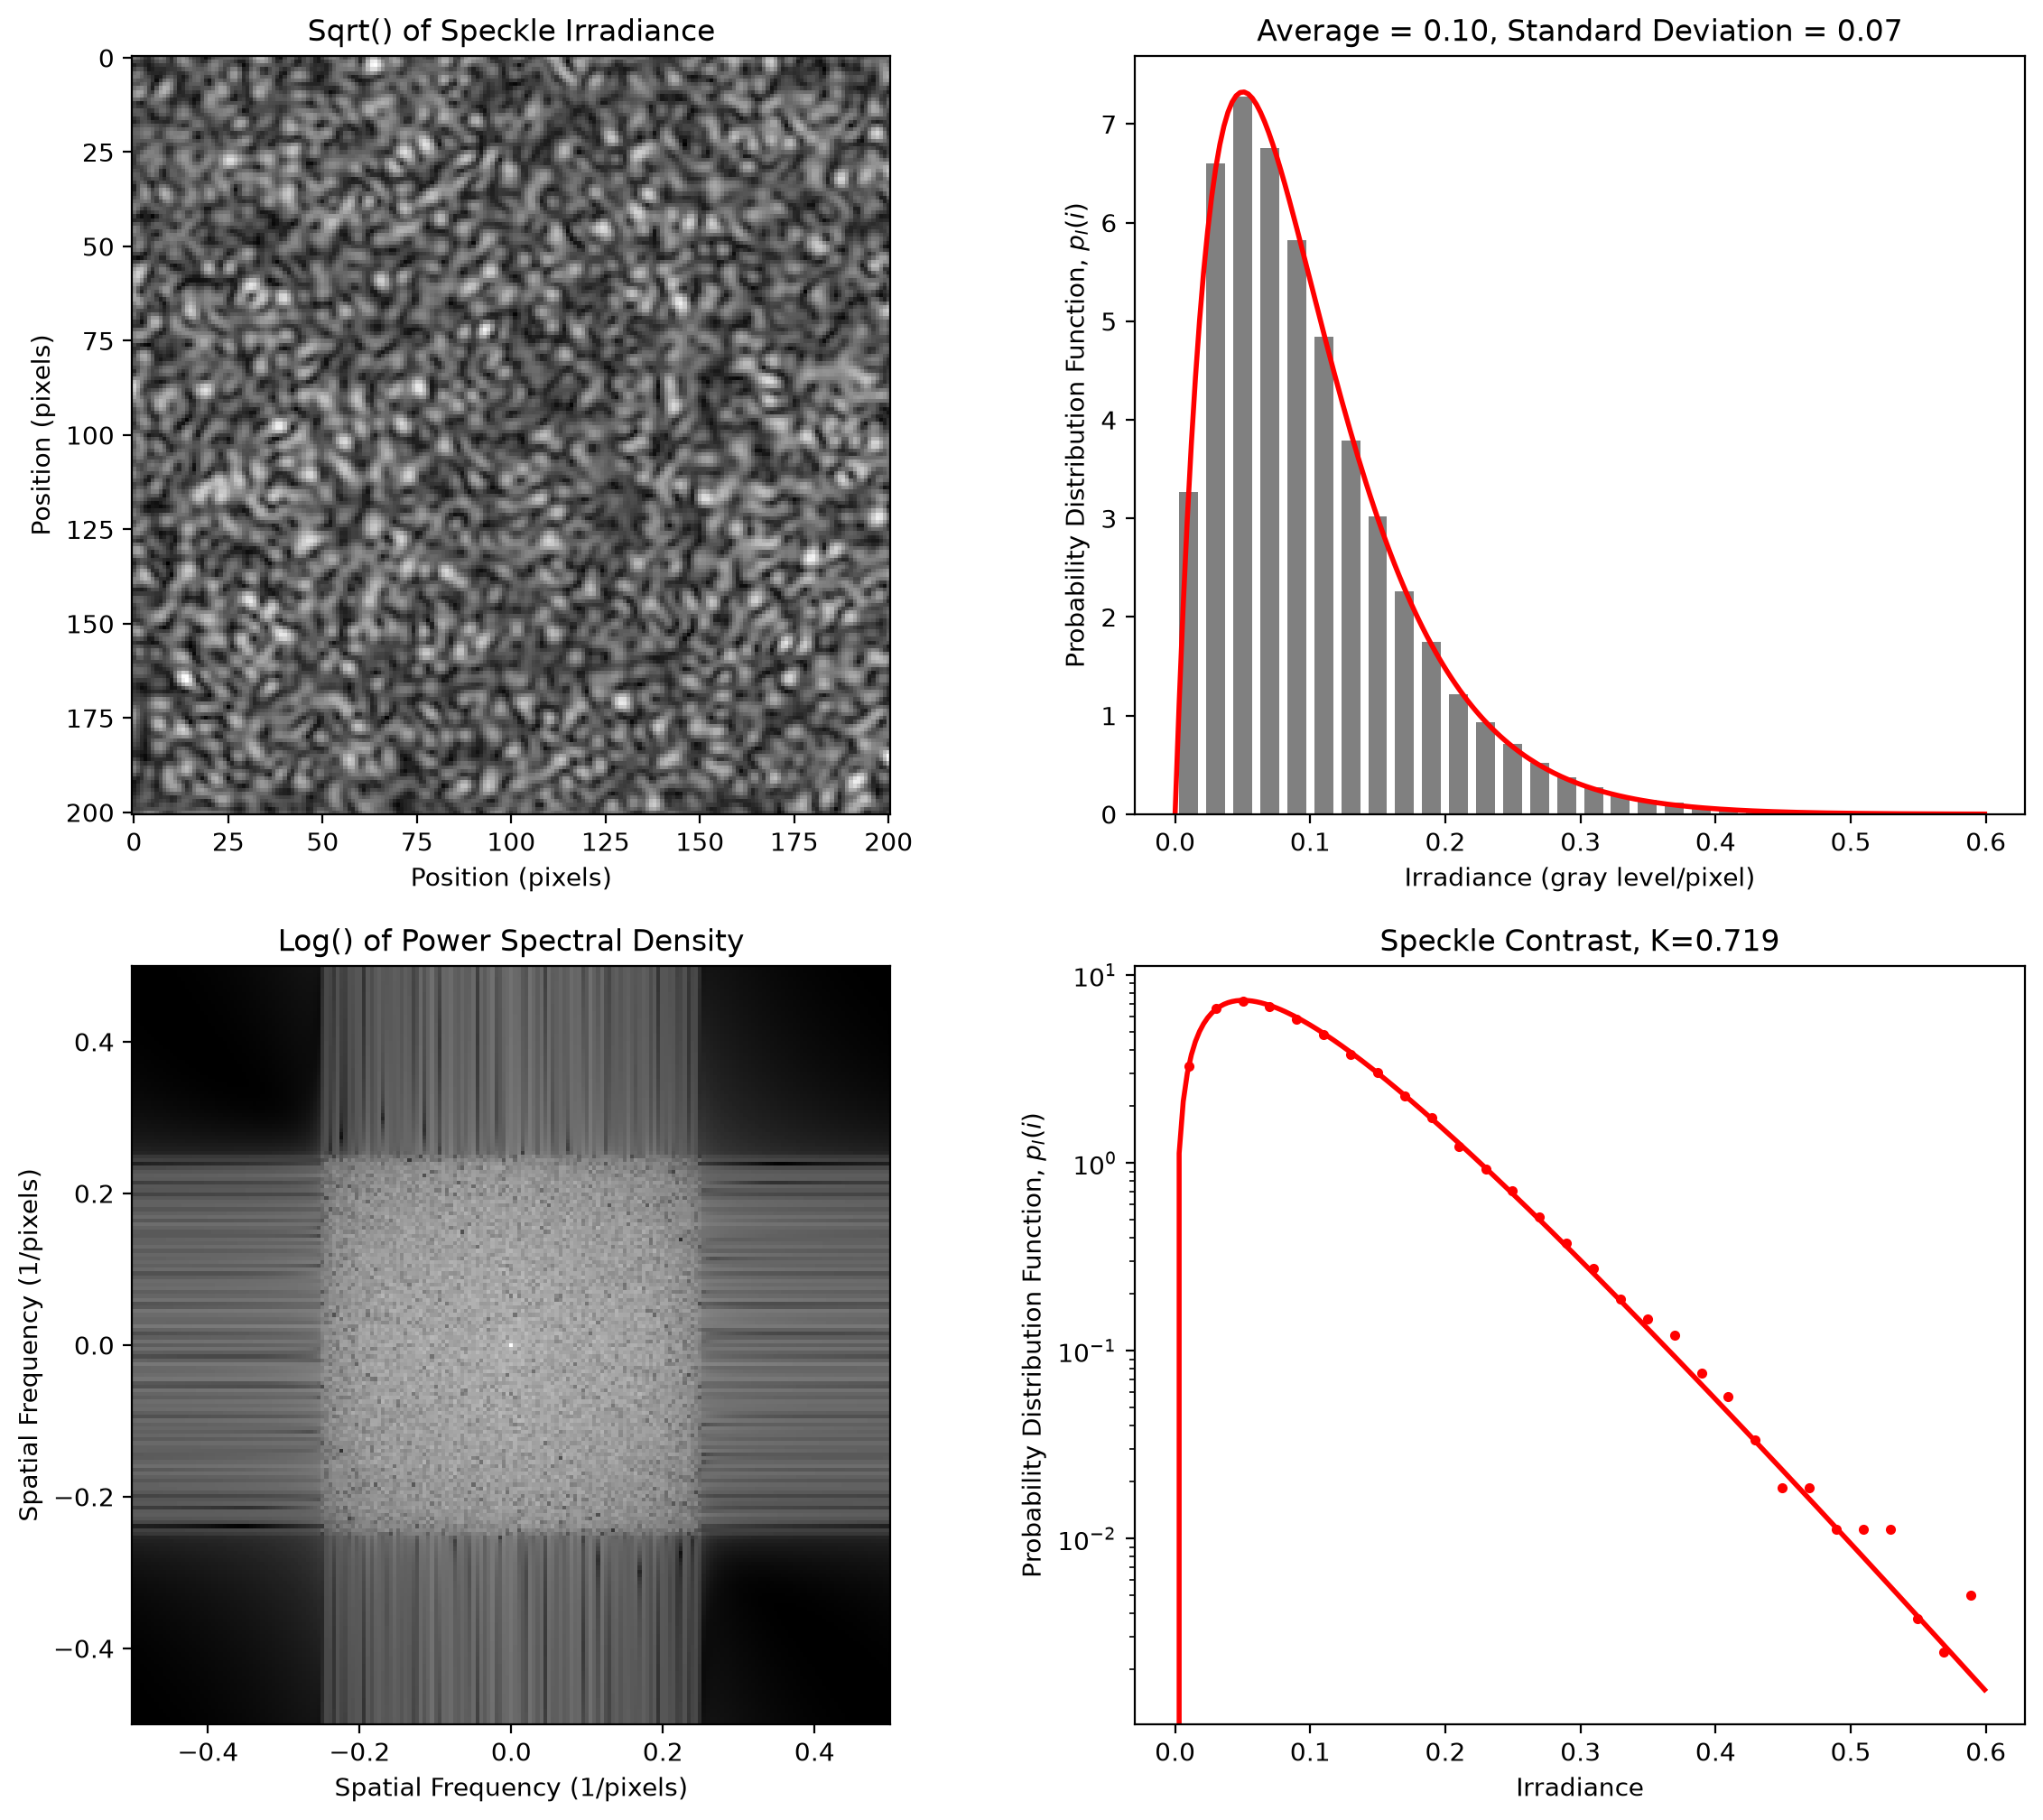

contrast K = 0.719 (theory 0.707)


In [9]:
y = pyspeckle.create_unpolarized((201, 201), 4, aperture="square")
pyspeckle.statistics_plot(y)
# unpolarized speckle adds two exponentials, so the theory is a gamma of shape 2
g = np.linspace(0, y.max(), 200)
scale = y.mean() / 2
pdf = g * np.exp(-g / scale) / scale**2
plt.subplot(222)
plt.plot(g, pdf, "r", lw=2)
plt.subplot(224)
plt.semilogy(g, pdf, "r", lw=2)

plt.show()

print("contrast K = %.3f (theory %.3f)" % (np.std(y) / np.mean(y), 1 / np.sqrt(2)))

## Partially developed speckle

Everything above assumed a surface rough enough to spread the phase over
$2\pi$.  A smoother surface leaves part of the light undeviated, and the
speckle is only partially developed.

`create_phase_screen((M, M), sigma, cl)` generates the phase such a surface
imposes: a zero-mean Gaussian random field of standard deviation `sigma`
radians with correlation length `cl` pixels.  The correlation is isotropic.

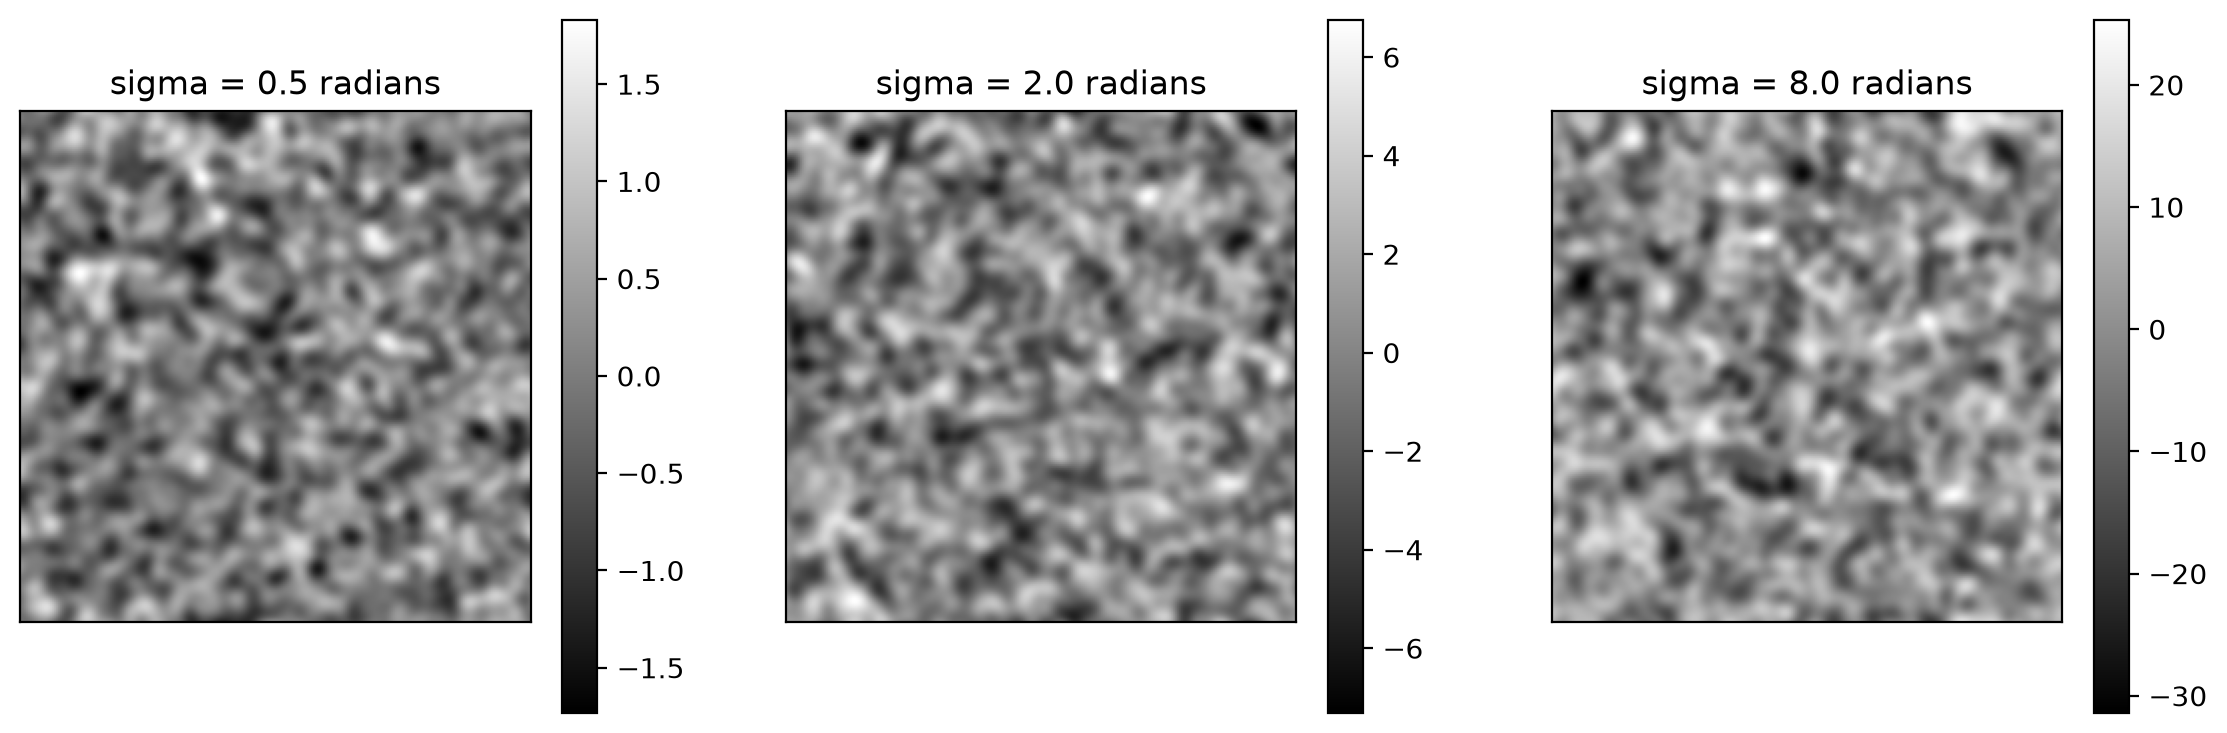

In [10]:
plt.subplots(1, 3, figsize=(14, 4.5))
for i, sigma in enumerate([0.5, 2.0, 8.0]):
    plt.subplot(1, 3, i + 1)
    screen = pyspeckle.create_phase_screen((256, 256), sigma, 8)
    plt.imshow(screen, cmap="gray")
    plt.title("sigma = %.1f radians" % sigma)
    plt.xticks([])
    plt.yticks([])
    plt.colorbar()

plt.show()

### How much light is scattered

The fraction of the field left undeviated is

$$
\left|\langle e^{i\phi}\rangle\right|^2 = e^{-\sigma^2}
$$

so a screen with $\sigma=0.5$ radians leaves 78% of the light unscattered
while $\sigma=3$ leaves essentially none.

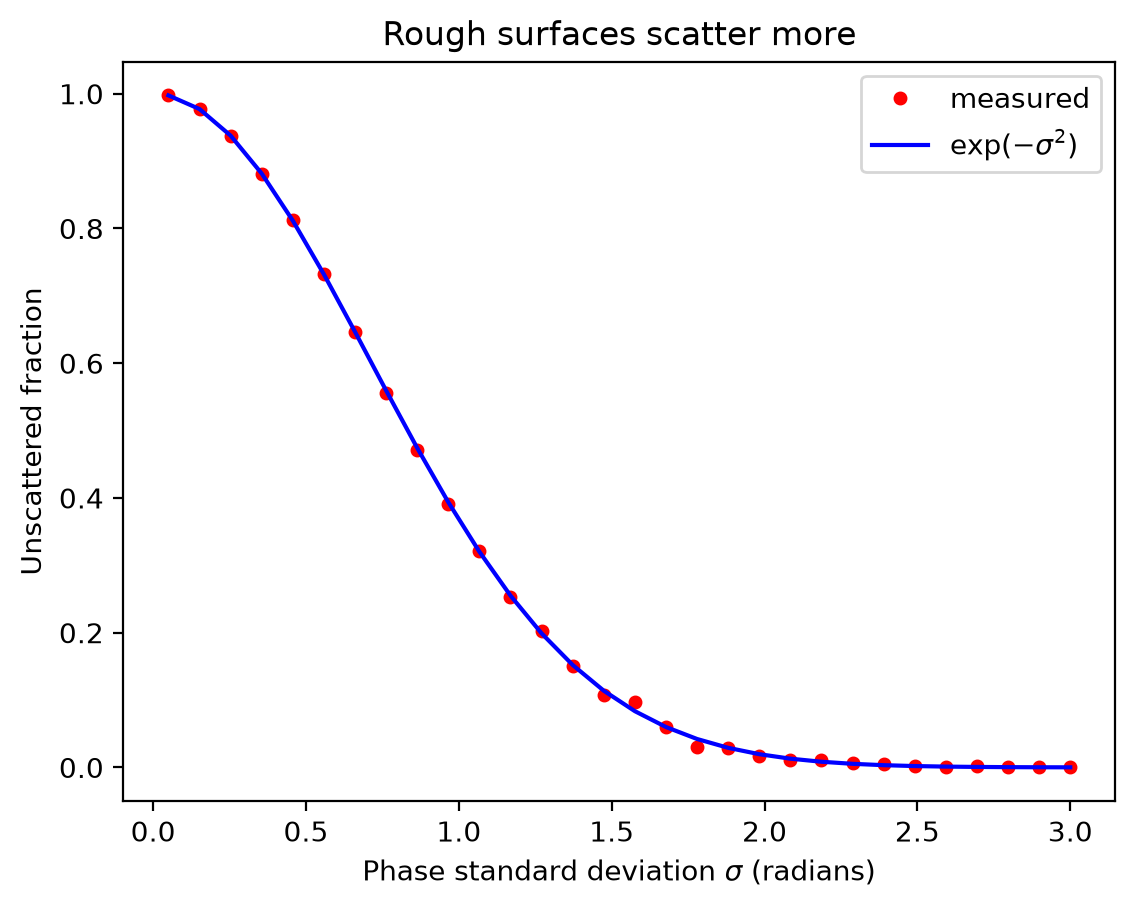

In [11]:
sigmas = np.linspace(0.05, 3, 30)
measured = [abs(np.mean(np.exp(1j * pyspeckle.create_phase_screen((256, 256), s, 8)))) ** 2 for s in sigmas]

plt.plot(sigmas, measured, "ro", markersize=4, label="measured")
plt.plot(sigmas, np.exp(-(sigmas**2)), "b", label=r"$\exp(-\sigma^2)$")
plt.xlabel(r"Phase standard deviation $\sigma$ (radians)")
plt.ylabel("Unscattered fraction")
plt.title("Rough surfaces scatter more")
plt.legend()
plt.show()

### From partially to fully developed

Illuminating an aperture with the screen and transforming gives the speckle.
For small `sigma` most of the energy stays in the undeviated spike at the
centre.  As `sigma` grows the spike disappears and the statistics approach the
fully developed values of $K=1$ and skew $=2$.

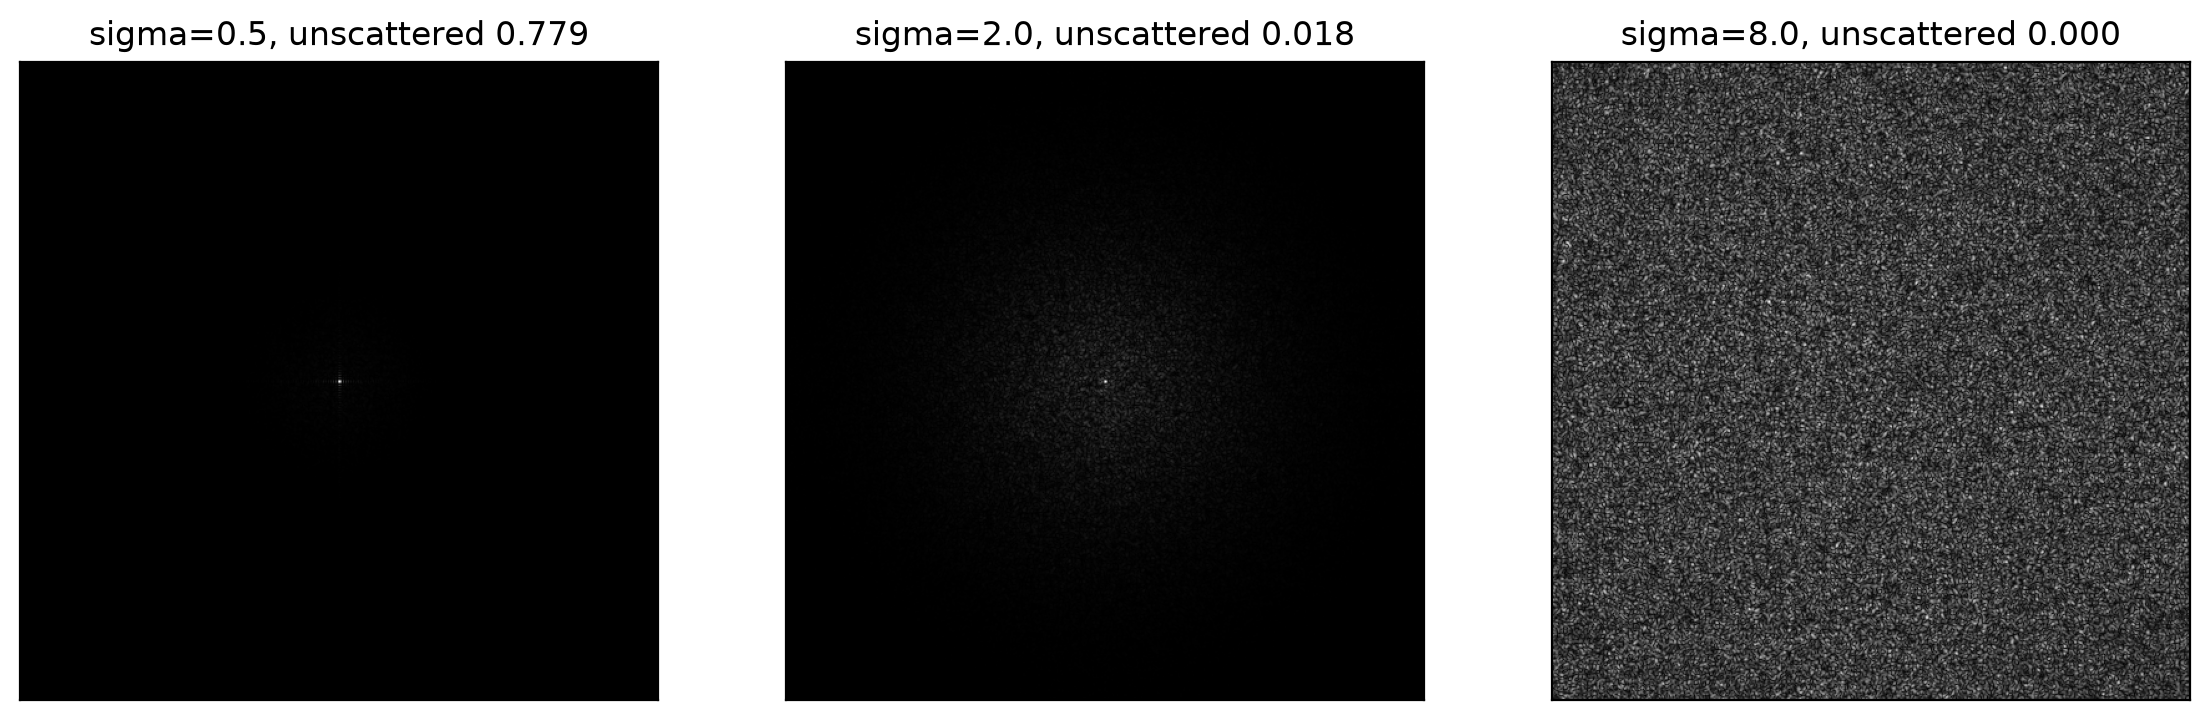

In [12]:
M, L, cl = 256, 512, 4

plt.subplots(1, 3, figsize=(14, 4.5))
for i, sigma in enumerate([0.5, 2.0, 8.0]):
    plt.subplot(1, 3, i + 1)
    u = np.exp(1j * pyspeckle.create_phase_screen((L, L), sigma, cl))
    u[M:, :] = 0
    u[:, M:] = 0
    speckle = np.abs(np.fft.fftshift(np.fft.fft2(u))) ** 2
    plt.imshow(np.sqrt(speckle), cmap="gray")
    plt.title("sigma=%.1f, unscattered %.3f" % (sigma, np.exp(-(sigma**2))))
    plt.xticks([])
    plt.yticks([])

plt.show()

In [13]:
M, L, cl = 256, 512, 4

print("  sigma   unscattered      K     skew")
for sigma in [0.5, 1.0, 2.0, 4.0, 8.0]:
    u = np.exp(1j * pyspeckle.create_phase_screen((L, L), sigma, cl))
    u[M:, :] = 0
    u[:, M:] = 0
    speckle = np.abs(np.fft.fftshift(np.fft.fft2(u))) ** 2

    middle = L // 2
    keep = np.ones(speckle.shape, dtype=bool)
    keep[middle - 16 : middle + 16, middle - 16 : middle + 16] = False  # drop the spike
    kept = speckle[keep]
    skew = np.mean(((kept - kept.mean()) / kept.std()) ** 3)
    print("  %5.1f      %7.3f  %7.2f  %7.2f" % (sigma, np.exp(-(sigma**2)), kept.std() / kept.mean(), skew))

reference = pyspeckle.create_exponential((256, 256), 4)
skew = np.mean(((reference - reference.mean()) / reference.std()) ** 3)
print("\n  fully developed reference: K=%.2f, skew=%.2f" % (np.std(reference) / np.mean(reference), skew))

  sigma   unscattered      K     skew
    0.5        0.779     7.02    18.90
    1.0        0.368     5.84    13.63
    2.0        0.018     3.59     8.41
    4.0        0.000     1.51     3.78
    8.0        0.000     1.00     1.97

  fully developed reference: K=1.00, skew=2.05


## Boiling speckle

Everything so far has been a single frozen pattern.  When the object moves,
the speckle changes, and `create_boiling_speckle` produces that sequence.

A single random-phase screen is illuminated through a circular pupil and the
pupil is translated one column per frame.  This is the back focal plane
geometry: the pattern seethes without appearing to travel, which is why it is
described as boiling.  Once the pupil has moved its own diameter the pattern
has forgotten where it started.

The function returns the cube, the correlation of each frame with the first,
and the correlation predicted by theory.

In [14]:
M = 128
cube, correlation, theory = pyspeckle.create_boiling_speckle((M, M), 2)

print("cube shape          ", cube.shape)
print("frames              ", cube.shape[2])
print("contrast of frame 0  %.3f" % (np.std(cube[:, :, 0]) / np.mean(cube[:, :, 0])))

cube shape           (128, 128, 129)
frames               129
contrast of frame 0  0.997


Each frame is an ordinary fully developed speckle pattern.  Stepping through
the cube shows the pattern reorganizing itself; by the last frame nothing of
the first remains.

`R/D` below is the pupil displacement as a fraction of its diameter.

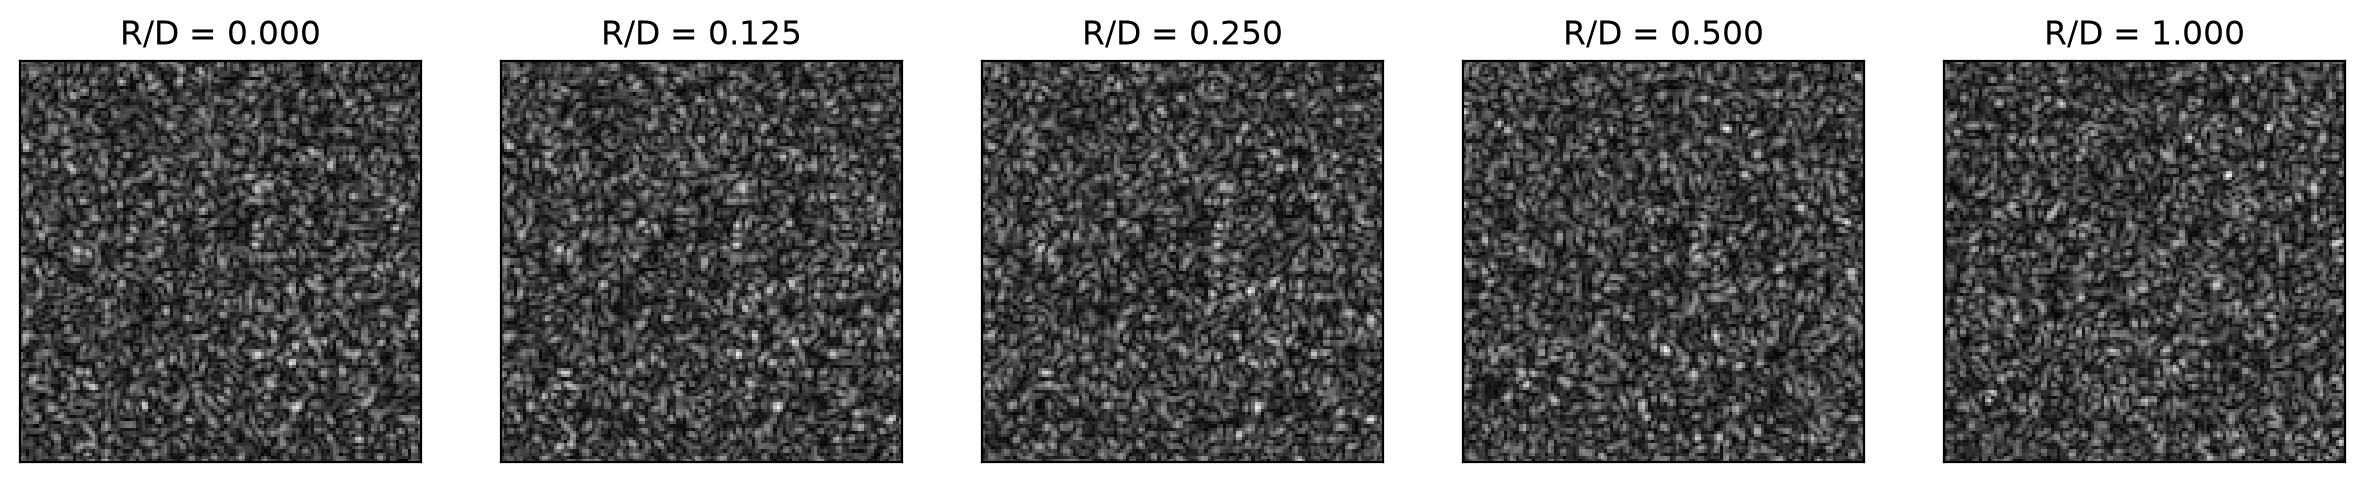

In [15]:
lags = [0, M // 8, M // 4, M // 2, M]

plt.subplots(1, len(lags), figsize=(15, 3.4))
for i, frame in enumerate(lags):
    plt.subplot(1, len(lags), i + 1)
    plt.imshow(np.sqrt(cube[:, :, frame]), cmap="gray", vmin=0, vmax=1)
    plt.title("R/D = %.3f" % (frame / M))
    plt.xticks([])
    plt.yticks([])

plt.show()

### Decorrelation follows the aperture

The correlation coefficient has a closed form for this geometry.  The speckle
correlation is simply the square of the autocorrelation of a circular disc,

$$
\mathrm{ACF}(a) = \frac{2}{\pi}\cos^{-1}\left( a - a\sqrt{1-a^2}\right),
\qquad \rho = \mathrm{ACF}^2
$$

with $a = R/D$.  The measured curve follows it without any fitting.

A single realization wanders a little around the prediction, more so for small
images; averaging several realizations converges on it.

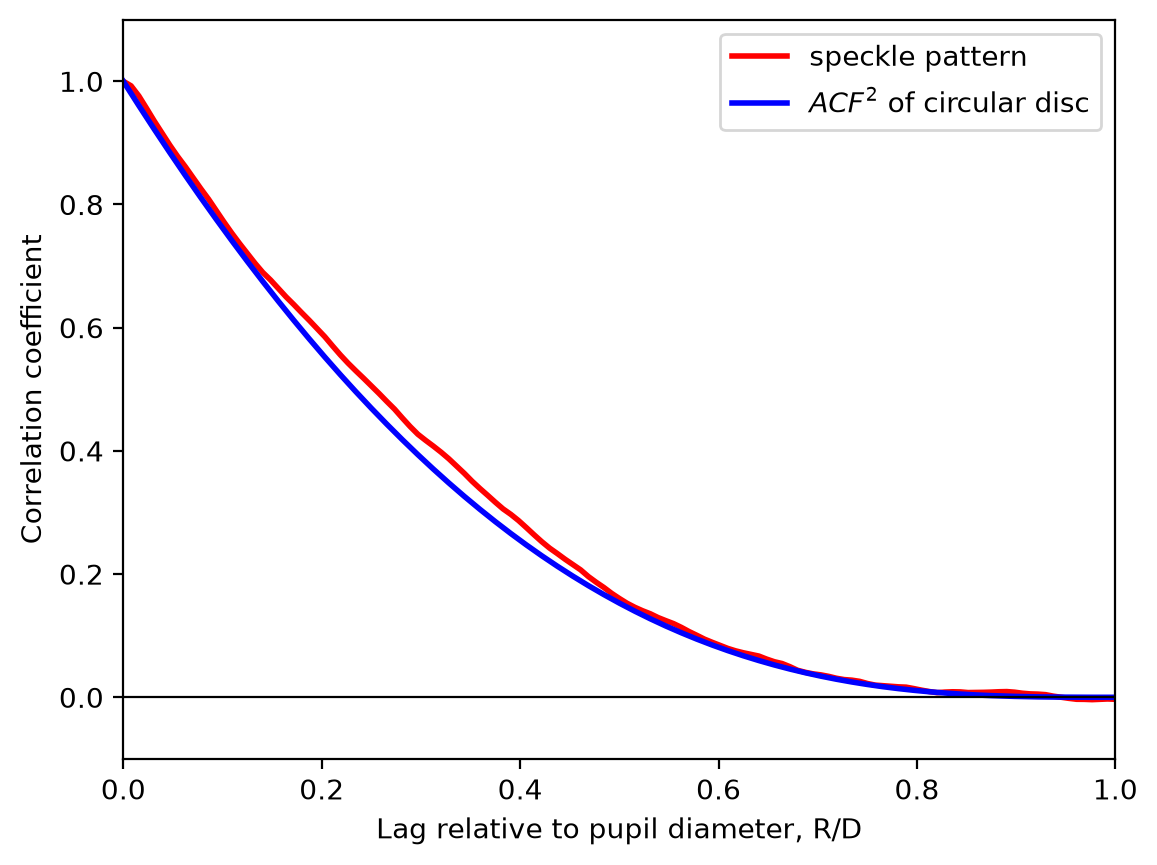

largest departure from theory: 0.039


In [16]:
lag = np.arange(len(correlation)) / M

plt.plot(lag, correlation, "r-", lw=2, label="speckle pattern")
plt.plot(lag, theory, "b-", lw=2, label="$ACF^2$ of circular disc")
plt.axhline(0, color="black", lw=0.8)
plt.xlabel("Lag relative to pupil diameter, R/D")
plt.ylabel("Correlation coefficient")
plt.axis([0, 1, -0.1, 1.1])
plt.legend()
plt.show()

print("largest departure from theory: %.3f" % np.max(np.abs(correlation - theory)))

Because the cube is an ordinary three-dimensional array with the frame on its
last axis, `slice_plot` displays it directly.  The constant-Z panel is one
speckle pattern; the other two are space-time cuts, where the streaks show
how long a given point stays bright as the pattern boils.

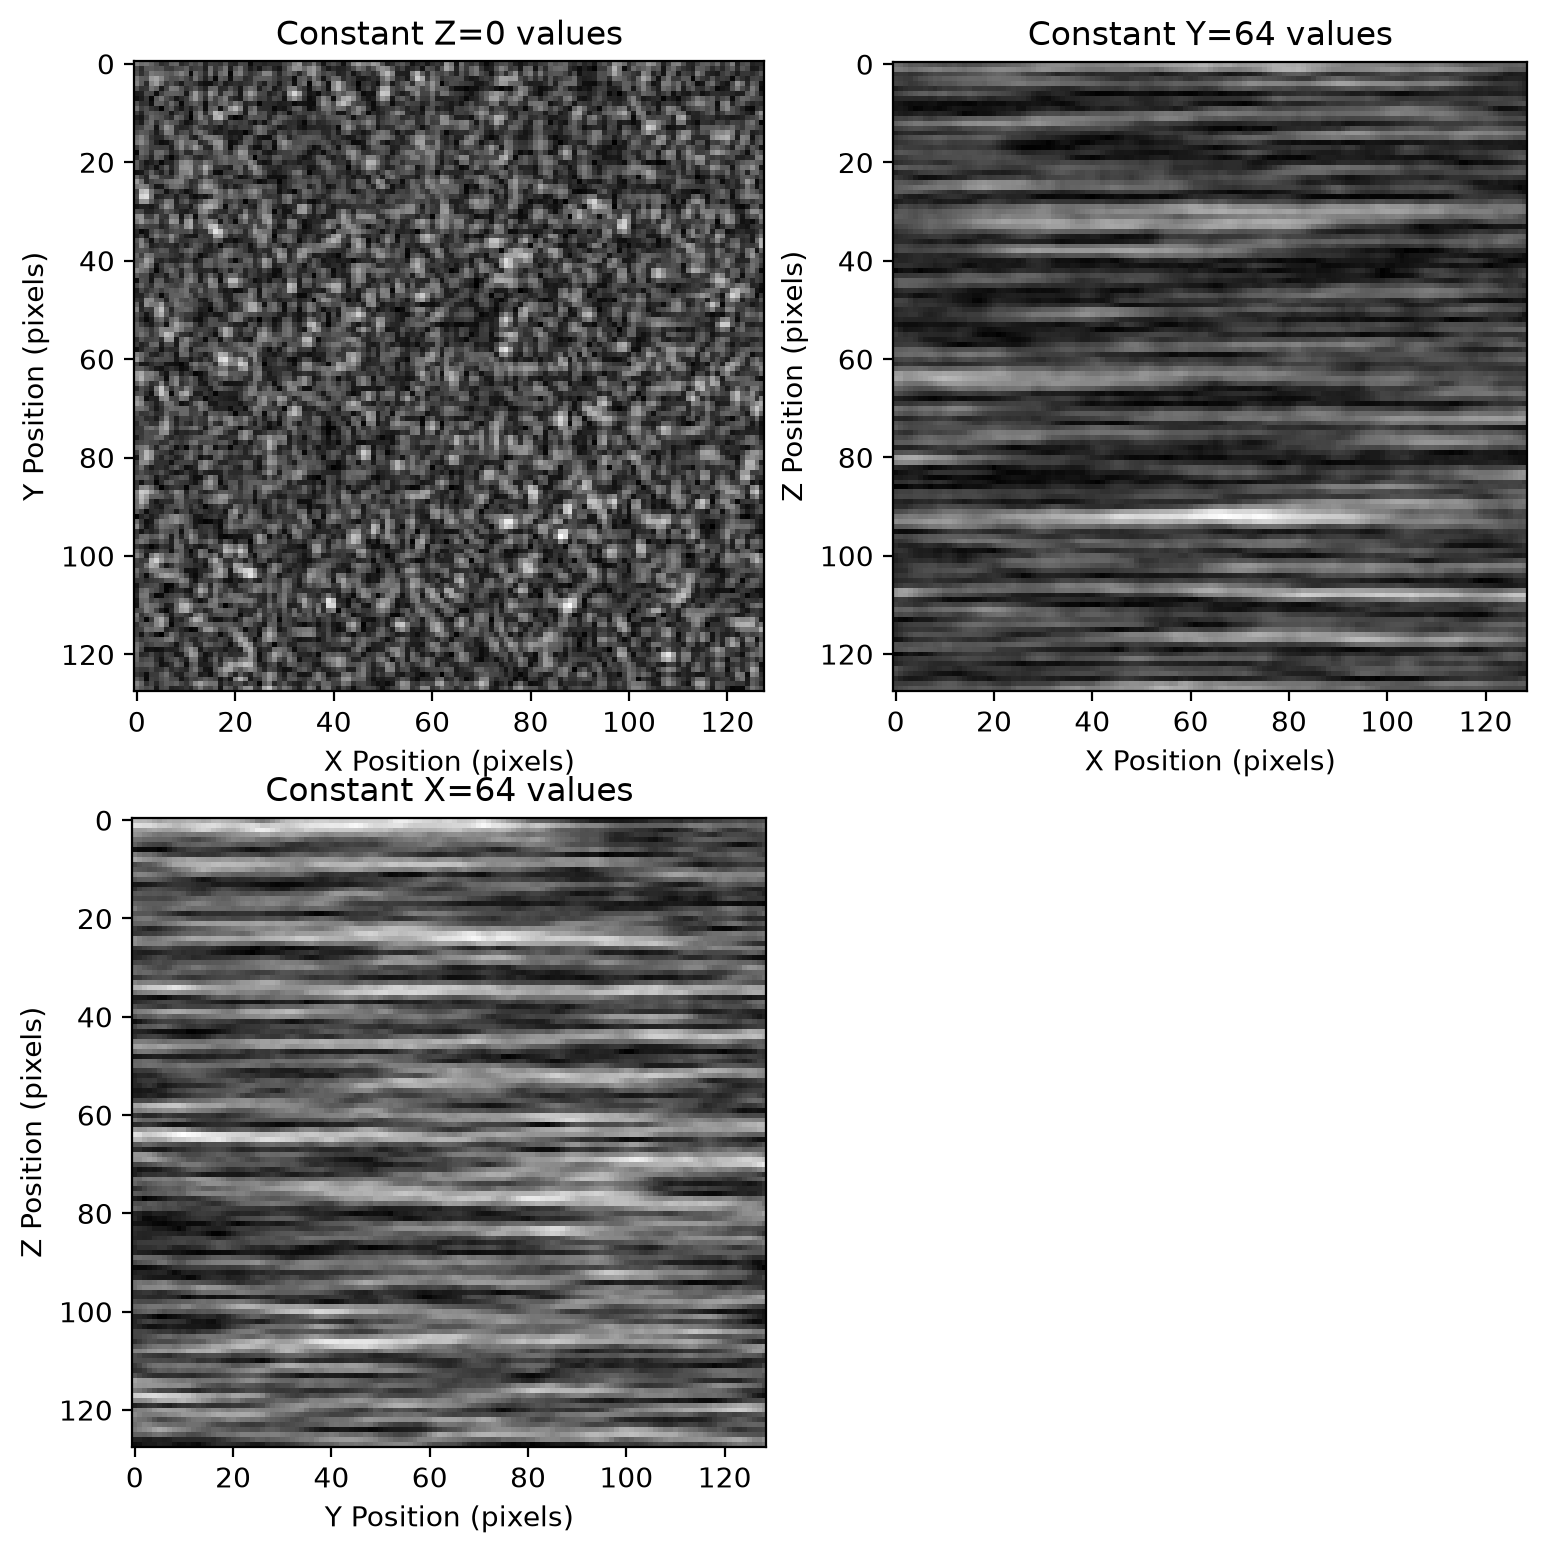

In [17]:
pyspeckle.slice_plot(cube, M // 2, M // 2, 0)
plt.show()

## Local contrast

Speckle contrast is often measured over a sliding window rather than over a
whole image, because the window can follow variation across a scene.
`local_contrast_2D` correlates the pattern with a kernel and returns the
contrast at every valid position, together with the contrast of the whole
image.

Here it is applied to a measured speckle image rather than a simulated one.

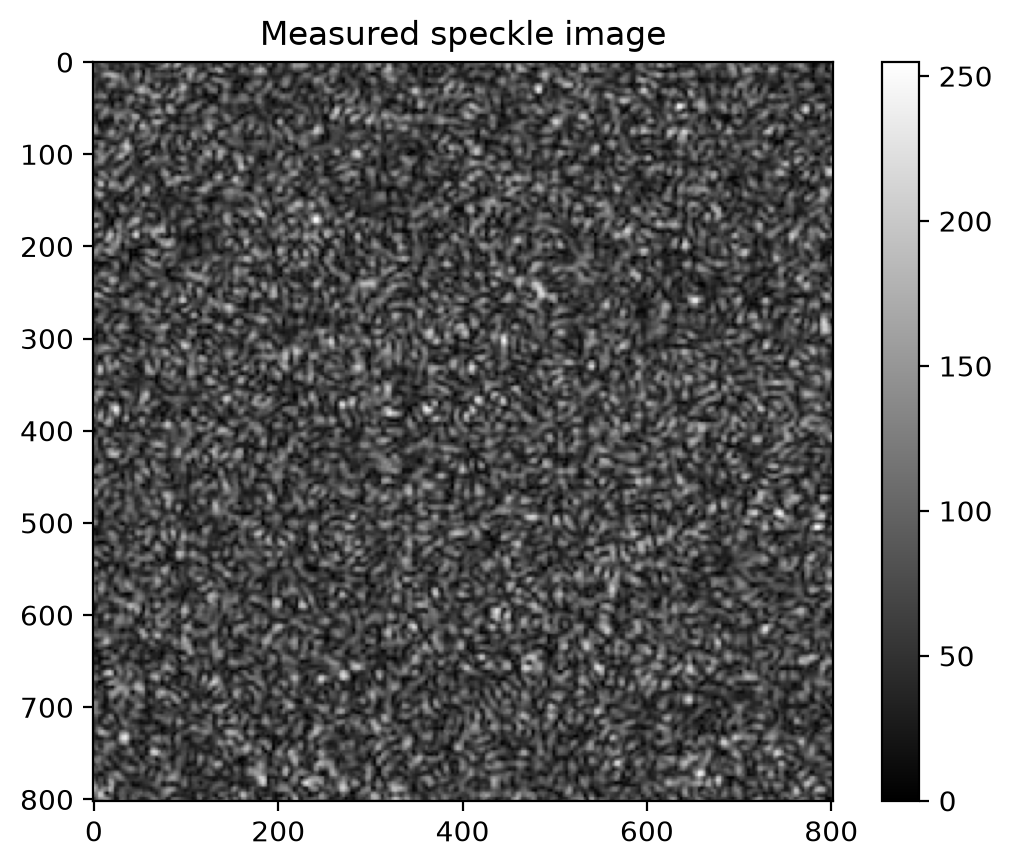

In [18]:
im = imageio.v2.imread(repo + "speckle.png")
plt.imshow(im, cmap="gray")
plt.colorbar()
plt.title("Measured speckle image")
plt.show()

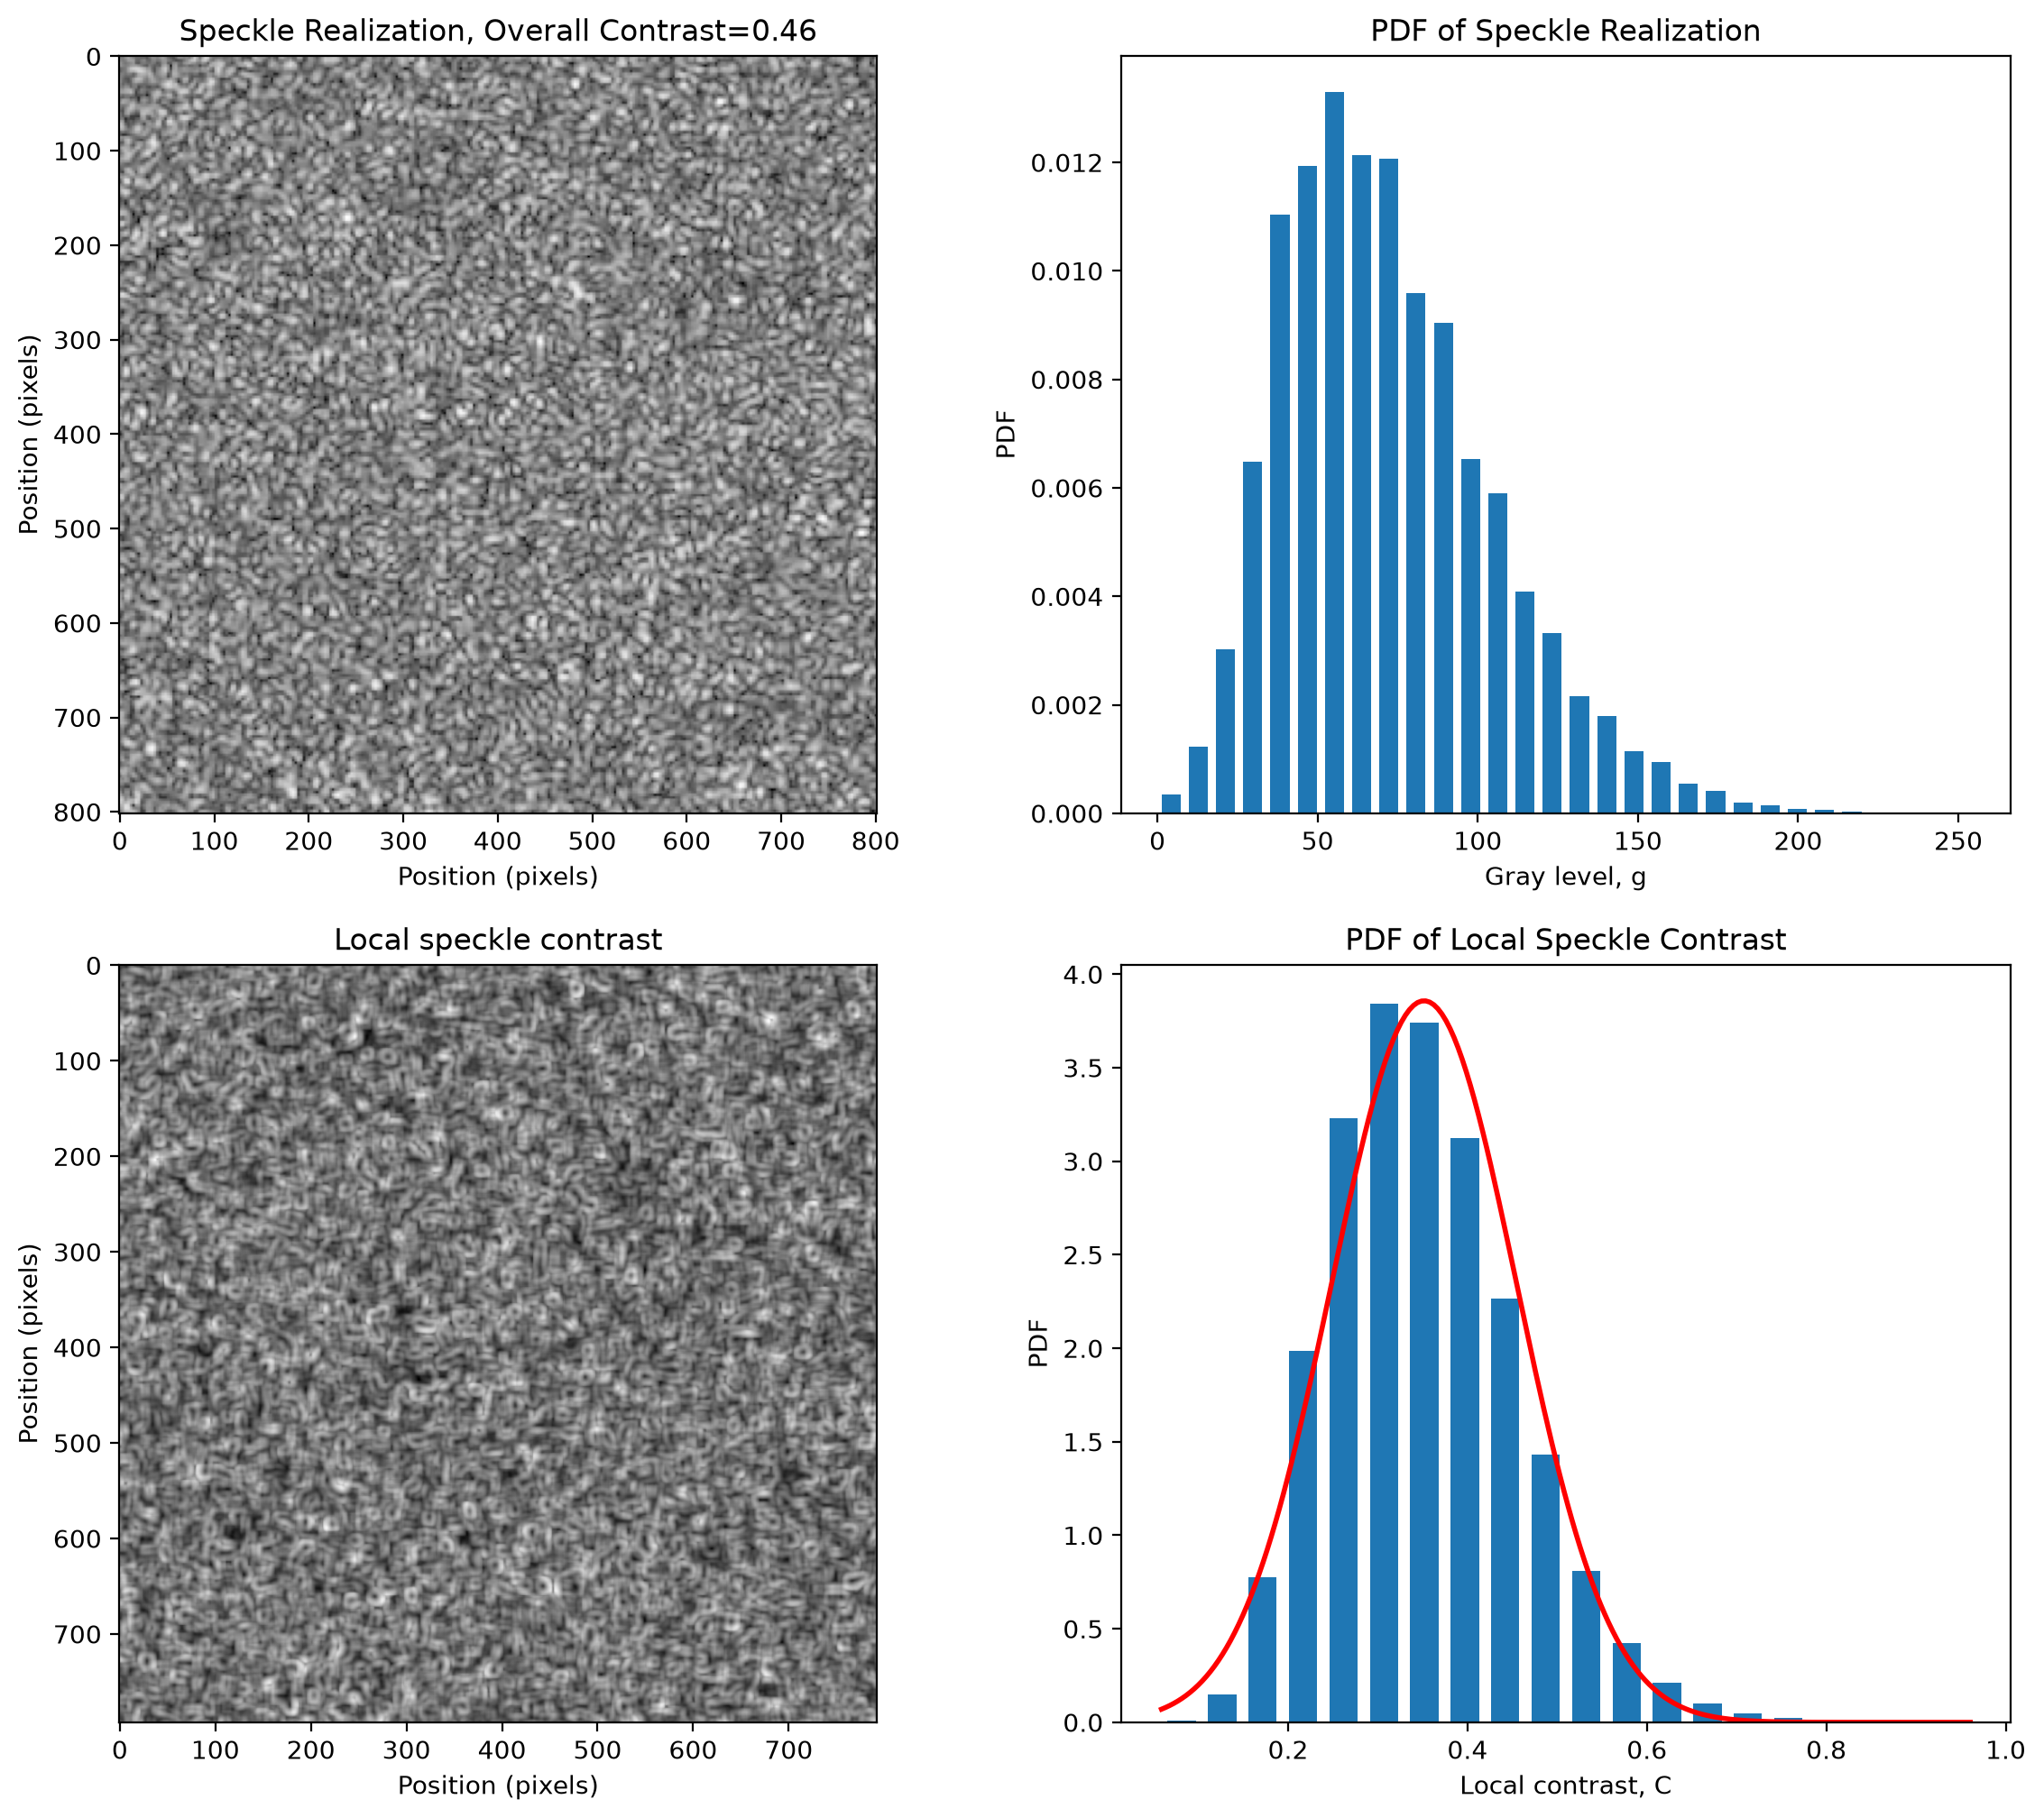

In [19]:
kernel = np.ones((10, 10))
pyspeckle.local_contrast_plot(im, kernel)
# no theory curve on the irradiance panel: this is a measured image, not a
# generated one, and its contrast of about 0.46 shows it is not fully developed
plt.subplot(224)
C, _ = pyspeckle.local_contrast(im, kernel)
c = np.linspace(C.min(), C.max(), 200)
plt.plot(c, np.exp(-((c - C.mean()) ** 2) / (2 * C.std() ** 2)) / (C.std() * np.sqrt(2 * np.pi)), "r", lw=2)

plt.show()

## Summary

* the aperture sets the speckle size and shape; `pix_per_speckle`, `alpha`, and
  `shape` all act through it
* `create_exponential` gives fully developed polarized speckle with
  exponential irradiance and contrast 1
* `create_unpolarized` gives contrast $1/\sqrt{2}$
* `create_phase_screen` provides the rough-surface phase needed for
  partially developed speckle
* `create_boiling_speckle` produces a decorrelating sequence, with the
  correlation coefficient and its theoretical prediction
* `local_contrast_2D` and `local_contrast_plot` measure contrast over a
  sliding window